# Asteroid orbit optimization with PyGMO - Optimization - spherical harmonics -  true shape - high fidelity
Copyright (c) 2010-2022, Delft University of Technology. All rights reserved. This file is part of the Tudat. Redistribution  and use in source and binary forms, with or without modification, are permitted exclusively under the terms of the Modified BSD license. You should have received a copy of the license with this file. If not, please or visit: http://tudat.tudelft.nl/LICENSE.

## Objectives
This tutorial is the third part of the Asteroid Orbit Optimization example. **This page reuses the** [Custom environment](aoo_custom_environment.ipynb) **part of the example, without the explanation, after which an optimization is executed.**

## Problem recap
This aim of this tutorial is to illustrate the use of PyGMO to optimize an astrodynamics problem simulated with tudatpy. The problem describes the orbit design around a small body, the [Themis asteroid](https://en.wikipedia.org/wiki/25143_Themis).

The 4 design variables are:

- initial values of the semi-major axis.
- initial eccentricity.
- initial inclination.
- initial longitude of the ascending node.
 
The 2 objectives are:

- good coverage (maximizing the mean value of the absolute longitude w.r.t. Themis over the full propagation).
- good resolution (the mean value of the distance should be minimized).
 
The constraints are set on the altitude: all the sets of design variables leading to an orbit.

### NOTE
It is assumed that the reader of this tutorial is already familiar with the content of [this basic PyGMO tutorial](https://docs.tudat.space/en/latest/_src_advanced_topics/optimization_pygmo.html). The full PyGMO documentation is available [on this website](https://esa.github.io/pygmo2/index.html). Be careful to read the
correct the documentation webpage (there is also a similar one for previous yet now outdated versions [here](https://esa.github.io/pygmo/index.html); as you can see, they can easily be confused).
PyGMO is the Python counterpart of [PAGMO](https://esa.github.io/pagmo2/index.html).

## Import statements

In [1]:
# Load standard modules
import os
import numpy as np
# Uncomment the following to make plots interactive
# %matplotlib widget
from matplotlib import pyplot as plt
from itertools import combinations as comb


# Load tudatpy modules
from tudatpy.data import save2txt
from tudatpy import constants
from tudatpy.interface import spice
from tudatpy.astro import element_conversion
from tudatpy.astro import frame_conversion
from tudatpy.dynamics import environment_setup
from tudatpy.dynamics import propagation_setup
from tudatpy.dynamics import simulator
import tudatpy.util as util

# Load pygmo library
import pygmo as pg

current_dir = os.path.abspath('')

## Creation of Custom Environment

### Themis rotation settings

In [2]:
def get_Themis_rotation_settings(Themis_body_frame_name):
    # Definition of initial Themis orientation conditions through the pole orientation
    pole_declination = np.deg2rad(59.8)     # Declination
    pole_right_ascension = np.deg2rad(125.6)  # Right ascension
    meridian_at_epoch = 0.0                   # Meridian

    # Define initial Themis orientation in inertial frame (equatorial plane)
    initial_orientation_j2000 = frame_conversion.inertial_to_body_fixed_rotation_matrix(
        pole_declination, pole_right_ascension, meridian_at_epoch)
    
    # Get initial Themis orientation in inertial frame but in the Ecliptic plane
    initial_orientation_eclipj2000 = np.matmul(spice.compute_rotation_matrix_between_frames(
        "J2000", "ECLIPJ2000", 0.0), initial_orientation_j2000)

    # Manually check the results, if desired
    check_results = False
    if check_results:
        np.set_printoptions(precision=100)
        print(initial_orientation_j2000)
    
        print(initial_orientation_eclipj2000)

    # Compute rotation rate
    # rotation_rate = np.deg2rad(712.143) / constants.JULIAN_DAY
    rotation_period = 8.374187 * 3600.0

    rotation_rate = 2.0 * np.pi / rotation_period

    # Set up rotational model for Themis with constant angular velocity
    return environment_setup.rotation_model.simple(
        "ECLIPJ2000", Themis_body_frame_name, initial_orientation_eclipj2000, 0.0, rotation_rate)

### Themis ephemeris settings

In [3]:
def get_Themis_ephemeris_settings(sun_gravitational_parameter):
    # Define Themis initial Kepler elements
    Themis_kepler_elements = np.array([
        3.1433 * constants.ASTRONOMICAL_UNIT,
        1.153499536381607E-01,
        np.deg2rad(7.366995500522935E-01),
        np.deg2rad(1.091193307580024E+02),
        np.deg2rad(3.639222711771391E+01),
        np.deg2rad(6.046711080424205E+01)])
    
    # Convert mean anomaly to true anomaly
    Themis_kepler_elements[5] = element_conversion.mean_to_true_anomaly(
        eccentricity=Themis_kepler_elements[1],
        mean_anomaly=Themis_kepler_elements[5])
    
    # Get epoch of initial Kepler elements (in Julian Days) 2025-Dec-12 00:00:00.0000
    kepler_elements_reference_julian_day = 2461021.5
    
    # Sets new reference epoch for Themis ephemerides (different from J2000)
    kepler_elements_reference_epoch = (kepler_elements_reference_julian_day - constants.JULIAN_DAY_ON_J2000) \
                                      * constants.JULIAN_DAY
    
    # Sets the ephemeris model
    return environment_setup.ephemeris.keplerian(
        Themis_kepler_elements,
        kepler_elements_reference_epoch,
        sun_gravitational_parameter,
        "Sun",
        "ECLIPJ2000")

### Themis gravity field settings

In [4]:
def get_Themis_gravity_field_settings(Themis_body_fixed_frame, Themis_radius):
    
    Themis_gravitational_parameter = 3.8e8  # m^3/s^2 — update if you have better value

    # 11x11 matrix → degrees 0-10, orders 0-10
    # Replace these with your actual data
    normalized_cosine_coefficients = np.array([
        [1.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=0
        [4.00437049323391e-10,      -2.00118621702933e-10,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=1
        [-0.0311484302600628, -0.00247282373836691,   -0.00274461339769334,  0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=2
        [-0.00200571383331492, -0.000432075164317321, 0.00194227892499834,0.00137270957639051, 0.0,    0.0,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=3
        [0.00285332640564815,  0.00110182963502399, -0.000735718367676304, 0.000724745021813717, 0.00176998960899976, 0.0,   0.0,      0.0,      0.0,      0.0,      0.0],   # n=4
        [0.000830075337320937,      0.000287519798138761,      -0.000528107896235689,      -0.000867730821110781,      4.79023000648861e-05,      0.000879439295195050,      0.0,      0.0,      0.0,      0.0,      0.0],   # n=5  ← your data
        [-0.000675558666706258,     -0.000205585971704600,      -0.000221135345635429,     -0.000318618655804238,      -0.000888434175048908,      -8.73422067817230e-05,     -0.000661361102590928,      0.0,      0.0,      0.0,      0.0],   # n=6
        [-0.000248341594690701,      -0.000163829109924533,      0.000232085380551457,      0.000258506065235110,      0.000160180230193337,      -0.000286377268939702,      6.77821275261500e-05,     0.000157407479968084,      0.0,      0.0,      0.0],   # n=7
        [0.000335217568650732,      -2.55140470111988e-05,      0.000274255269526383,      4.96324094064370e-05,      0.000342523466493208,     -1.86321450442635e-05,      0.000172675634502437,     9.50587862238274e-05,      0.000145987430976338,      0.0,      0.0],   # n=8
        [6.99720204690460e-05,      8.60097640010565e-05,      -0.000102732485716739,      -4.39268805337316e-05,      -0.000102645709362265,      0.000116936443373915,      -6.33826315277080e-05,      -5.20516633544555e-05,     -3.74472817959948e-05,      2.61212670888696e-05,      0.0],   # n=9
        [-0.000144111884090325,      2.32066521881085e-05,      -0.000126297847367392,      -2.62937726762541e-05,      -0.000124821278562081,      1.97212481561922e-05,      -4.97665457889904e-05,      -3.59202127991231e-05,      -7.28226920211166e-05,      1.23255404885492e-06,      -8.44844997134115e-05],   # n=10
    ])

    normalized_sine_coefficients = np.array([
        # m=0          m=1                        m=2                       m=3                       m=4                       m=5                       m=6                       m=7                       m=8                       m=9                       m=10
        [ 0.0,         0.0,                       0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=0
        [ 0.0,        -1.12918257515491e-09,       0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=1
        [ 0.0,         0.00107223359971325,       -0.00332663415194219,      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=2
        [ 0.0,        -0.00907886970678376,       -0.000235642226308041,    -0.00453797805800339,       0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=3
        [ 0.0,        -0.000236332856522398,       0.000679356889179597,     0.00103902654905862,      -0.00164525397614147,      0.0,                      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=4
        [ 0.0,         0.00311673748224299,       -0.000197902324683847,     0.000723574770295993,     7.12712231701076e-05,      0.000728705277735932,      0.0,                      0.0,                      0.0,                      0.0,                      0.0         ],  # n=5
        [ 0.0,         9.08985833204355e-05,      -7.81012920836034e-05,    -0.000382933168574949,     0.000417670991355626,     -0.000244616302121161,     -0.000272475519450808,     0.0,                      0.0,                      0.0,                      0.0         ],  # n=6
        [ 0.0,        -0.000726023965052120,      -0.000157289026194778,    -0.000151049434293496,    -1.31229025167918e-05,     -0.000180291881759017,      4.75861083370220e-05,     -0.000466425371326853,     0.0,                      0.0,                      0.0         ],  # n=7
        [ 0.0,        -4.66199482564515e-05,       4.07552978692181e-05,     0.000141144082038173,    -7.01025270851237e-05,      3.48820998708198e-05,      9.78492071833127e-05,      2.78823107064210e-05,     -0.000108013182515871,     0.0,                      0.0         ],  # n=8
        [ 0.0,         0.000177445235331498,       0.000124031343956387,     0.000102169331575207,     3.03402767376233e-05,      0.000131791270134196,      1.21961070494812e-05,      0.000178265283377157,      3.51673248637755e-05,      4.88474288152410e-05,     0.0         ],  # n=9
        [ 0.0,         7.90100853753287e-06,      -1.42280089749264e-05,    -7.29562295080795e-05,     2.77916592967652e-06,     -2.60570209403151e-05,     -2.33055610543032e-05,     -2.66308045112190e-05,      2.55117509946166e-05,     -3.32601179349906e-05,    -3.94450492257997e-06],  # n=10
    ])
    # ← UNCOMMENT this and remove the central() call below
    return environment_setup.gravity_field.spherical_harmonic(
        gravitational_parameter=Themis_gravitational_parameter,
        reference_radius=Themis_radius,
        normalized_cosine_coefficients=normalized_cosine_coefficients,
        normalized_sine_coefficients=normalized_sine_coefficients,
        associated_reference_frame=Themis_body_fixed_frame)

    # ← REMOVE this line (was placeholder, ignores all SH structure)
    # return environment_setup.gravity_field.central(
    #     gravitational_parameter=Themis_gravitational_parameter)

### Themis shape settings

In [5]:
def get_Themis_shape_settings(vertices, faces):
    """
    Polyhedral shape model.
    vertices : (N, 3) float64 array — Cartesian coordinates in metres
    faces    : (M, 3) int32 array  — 0-based vertex indices, CCW from outside
    """
    # ── Type enforcement — Tudat is strict about these dtypes ────────────────
    vertices_f64 = np.asarray(vertices, dtype=np.float64)   # must be float64
    faces_i32    = np.asarray(faces,    dtype=np.int32)      # must be int32 ← key fix

    # ── Winding order check — normals must point outward ─────────────────────
    centroid = vertices_f64.mean(axis=0)
    print('hi')
    print(centroid)
    n_inward = 0
    for f in faces_i32[:10]:                      # spot-check first 10 faces
        v0, v1, v2 = vertices_f64[f[0]], vertices_f64[f[1]], vertices_f64[f[2]]
        normal  = np.cross(v1 - v0, v2 - v0)
        if np.dot(normal, v0 - centroid) < 0:
            n_inward += 1
    if n_inward > 5:                              # majority inward → flip all
        print("[SHAPE] ⚠  Winding order is inward — flipping all faces")
        faces_i32 = faces_i32[:, ::-1]
    else:
        print("[SHAPE] ✓  Winding order looks correct (outward normals)")

    print(f"[SHAPE] Vertices: {vertices_f64.shape}  dtype={vertices_f64.dtype}")
    print(f"[SHAPE] Faces:    {faces_i32.shape}     dtype={faces_i32.dtype}")

    return environment_setup.shape.polyhedron(
        vertices_coordinates        = vertices_f64,   # ← correct kwarg name
        vertices_defining_each_facet= faces_i32,      # ← correct kwarg name
        compute_altitude_with_sign  = True,           # >0 above surface, <0 below
        just_compute_distance_to_vertices = False     # full accuracy (slower)
    )

### Simulation bodies

In [6]:
def create_simulation_bodies(Themis_radius, vertices, faces):
    Themis_body_frame_name = "Themis_Frame"
    bodies_to_create = ["Sun", "Earth", "Jupiter", "Saturn", "Mars"]

    body_settings = environment_setup.get_default_body_settings(
        bodies_to_create, "SSB", "ECLIPJ2000")

    body_settings.add_empty_settings("Themis")

    # Gravity: always SH 10x10
    body_settings.get("Themis").gravity_field_settings = \
        get_Themis_gravity_field_settings(Themis_body_frame_name, Themis_radius)

    body_settings.get("Themis").rotation_model_settings = \
        get_Themis_rotation_settings(Themis_body_frame_name)

    body_settings.get("Themis").ephemeris_settings = \
        get_Themis_ephemeris_settings(spice.get_body_gravitational_parameter('Sun'))

    # Shape: polyhedral — used for altitude computation and radiation occulting
    body_settings.get("Themis").shape_settings = \
        get_Themis_shape_settings(vertices, faces)

    ### VEHICLE ###
    body_settings.add_empty_settings("Spacecraft")
    body_settings.get("Spacecraft").constant_mass = 986
    reference_area_radiation = 65 + 2.4 * 2.2
    radiation_pressure_coefficient = 1.2
    occulting_bodies_dict = {"Sun": ["Themis"]}
    vehicle_target_settings = environment_setup.radiation_pressure.cannonball_radiation_target(
        reference_area_radiation, radiation_pressure_coefficient, occulting_bodies_dict)
    body_settings.get("Spacecraft").radiation_pressure_target_settings = vehicle_target_settings

    return environment_setup.create_system_of_bodies(body_settings)

### Acceleration models

In [7]:
def get_acceleration_models(bodies_to_propagate, central_bodies, bodies):
    # Define accelerations acting on Spacecraft
    accelerations_settings_spacecraft = dict(
        Sun =     [ propagation_setup.acceleration.radiation_pressure(),
                    propagation_setup.acceleration.point_mass_gravity() ],
        Themis = [ propagation_setup.acceleration.spherical_harmonic_gravity(10, 10) ],
        Jupiter = [ propagation_setup.acceleration.point_mass_gravity() ],
        Saturn =  [ propagation_setup.acceleration.point_mass_gravity() ],
        Mars =    [ propagation_setup.acceleration.point_mass_gravity() ],
        Earth =   [ propagation_setup.acceleration.point_mass_gravity() ]
    )

    # Create global accelerations settings dictionary
    acceleration_settings = {"Spacecraft": accelerations_settings_spacecraft}

    # Create acceleration models
    return propagation_setup.create_acceleration_models(
        bodies,
        acceleration_settings,
        bodies_to_propagate,
        central_bodies)

### Termination settings

In [8]:
def get_termination_settings(mission_initial_time, mission_duration,
                              minimum_altitude, maximum_altitude, Themis_radius):
    """
    Termination based on TRUE altitude above shape model surface.
    Works for both spherical and polyhedral shape models automatically.
    minimum_altitude / maximum_altitude in metres above surface.
    No Themis_radius offset needed — Tudat handles it via shape model.
    """
    # Time termination
    time_termination = propagation_setup.propagator.time_termination(
        mission_initial_time + mission_duration,
        terminate_exactly_on_final_condition=False
    )

    # Upper altitude limit — terminate if spacecraft goes too high
    upper_termination = propagation_setup.propagator.dependent_variable_termination(
        dependent_variable_settings=propagation_setup.dependent_variable.altitude(
            'Spacecraft', 'Themis'               # ← altitude above shape surface
        ),
        limit_value=maximum_altitude,             # metres above surface directly
        use_as_lower_limit=False,                 # terminate if altitude > max
        terminate_exactly_on_final_condition=False
    )

    # Lower altitude limit — terminate if spacecraft gets too close (crash risk)
    lower_termination = propagation_setup.propagator.dependent_variable_termination(
        dependent_variable_settings=propagation_setup.dependent_variable.altitude(
            'Spacecraft', 'Themis'
        ),
        limit_value=minimum_altitude,             # metres above surface directly
        use_as_lower_limit=True,                  # terminate if altitude < min
        terminate_exactly_on_final_condition=False
    )

    return propagation_setup.propagator.hybrid_termination(
        [time_termination, upper_termination, lower_termination],
        fulfill_single_condition=True
    )

### Dependent variables to save

In [9]:
def get_dependent_variables_to_save():
    return [
        # col 0,1,2 → r, lat, lon in body-fixed spherical coords
        propagation_setup.dependent_variable.central_body_fixed_spherical_position(
            "Spacecraft", "Themis"
        ),
        # col 3,4,5,6,7,8 → a, e, i, AoP, RAAN, TA
        propagation_setup.dependent_variable.keplerian_state(
            "Spacecraft", "Themis"
        ),
        # col 9 → true altitude above shape surface (polyhedral or spherical)
        propagation_setup.dependent_variable.altitude(
            "Spacecraft", "Themis"               # ← this is the key new one
        ),
        # col 10 → distance from CoM (keep for reference/debugging)
        propagation_setup.dependent_variable.relative_distance(
            "Spacecraft", "Themis"
        ),
    ]
    # Index reference:
    # dep_arr[:, 0]  = distance from CoM (spherical r)  [m]
    # dep_arr[:, 1]  = latitude                         [rad]
    # dep_arr[:, 2]  = longitude                        [rad]
    # dep_arr[:, 3]  = semi-major axis                  [m]
    # dep_arr[:, 4]  = eccentricity                     [-]
    # dep_arr[:, 5]  = inclination                      [rad]
    # dep_arr[:, 6]  = argument of periapsis            [rad]
    # dep_arr[:, 7]  = RAAN                             [rad]
    # dep_arr[:, 8]  = true anomaly                     [rad]
    # dep_arr[:, 9]  = TRUE altitude above surface      [m]  ← new
    # dep_arr[:, 10] = distance from CoM                [m]

## Optimisation problem formulation 

In [10]:
class AsteroidOrbitProblem:
 
    def __init__(self,
                 bodies,
                 propagator_settings,
                 mission_initial_time,
                 mission_duration,
                 design_variable_lower_boundaries,
                 design_variable_upper_boundaries,
                 Themis_radius,
                 minimum_altitude,
                 maximum_altitude,
                 lat_bins=18,     # 10° per bin  (18 × 10° = 180°)
                 lon_bins=36):    # 10° per bin  (36 × 10° = 360°)
 
        self.bodies_function              = lambda: bodies
        self.propagator_settings_function = lambda: propagator_settings
        self.dynamics_simulator_function  = lambda: None
        self.minimum_altitude = minimum_altitude
        self.maximum_altitude = maximum_altitude
        self.mission_initial_time         = mission_initial_time
        self.mission_duration             = mission_duration
        self.mission_final_time           = mission_initial_time + mission_duration
        self.design_variable_lower_boundaries = design_variable_lower_boundaries
        self.design_variable_upper_boundaries = design_variable_upper_boundaries
        self.Themis_radius                = Themis_radius
 
        # ── Precompute coverage grid cell areas ────────────────────────────
        # Exact spherical-strip formula:
        #   area of one cell = R² × |sin(lat_hi) - sin(lat_lo)| × Δlon
        # Normalised by R² so total ≈ 4π; we divide by total at the end.
        self.lat_bins = lat_bins
        self.lon_bins = lon_bins
 
        lat_edges = np.linspace(-np.pi / 2, np.pi / 2, lat_bins + 1)
        lon_edges = np.linspace(-np.pi, np.pi, lon_bins + 1)
        delta_lon = 2 * np.pi / lon_bins
 
        # cell_areas[i, j] = area of cell (lat-strip i, lon-strip j)  [R² units]
        lat_strip_areas   = np.diff(np.sin(lat_edges)) * delta_lon   # shape (lat_bins,)
        self.cell_areas   = np.outer(lat_strip_areas,
                                     np.ones(lon_bins))               # (lat_bins, lon_bins)
        self.total_surface = np.sum(self.cell_areas)                  # ≈ 4π
 
        # Bin edge arrays stored for fast searchsorted indexing
        self.lat_edges = lat_edges
        self.lon_edges = lon_edges
 
    # ── bounds ────────────────────────────────────────────────────────────────
    def get_bounds(self):
        return (list(self.design_variable_lower_boundaries),
                list(self.design_variable_upper_boundaries))
 
    # ── CHANGED: 2 objectives ─────────────────────────────────────────────────
    def get_nobj(self):
        return 2
 
    # ── CHANGED: fitness ──────────────────────────────────────────────────────
    def fitness(self, orbit_parameters):
 
        current_bodies                = self.bodies_function()
        Themis_gravitational_parameter = current_bodies.get("Themis").gravitational_parameter
 
        # Convert design variables → Cartesian initial state
        new_initial_state = element_conversion.keplerian_to_cartesian_elementwise(
            gravitational_parameter     = Themis_gravitational_parameter,
            semi_major_axis             = orbit_parameters[0],
            eccentricity                = orbit_parameters[1],
            inclination                 = np.deg2rad(orbit_parameters[2]),
            argument_of_periapsis       = np.deg2rad(235.7),
            longitude_of_ascending_node = np.deg2rad(orbit_parameters[3]),
            true_anomaly                = np.deg2rad(139.87))
 
        propagator_settings = self.propagator_settings_function()
        propagator_settings.initial_states = new_initial_state
 
        # Run propagation
        dynamics_simulator = simulator.create_dynamics_simulator(
            current_bodies, propagator_settings)
        self.dynamics_simulator_function = lambda: dynamics_simulator
 
        dep_hist = dynamics_simulator.propagation_results.dependent_variable_history
 
        # ── Propagation failed at t=0 ─────────────────────────────────────────
        if len(dep_hist) < 2:
            return [1.0, 1.0]   # worst possible for both objectives
 
        dep_arr  = np.vstack(list(dep_hist.values()))   # (N, 11)
        latitudes  = dep_arr[:, 1]   # rad
        longitudes = dep_arr[:, 2]   # rad
        sma_history = dep_arr[:, 3]  # semi-major axis [m]  (col 3 = keplerian a)
        alt_history = dep_arr[:, 9] 
        # ── Survival fraction (smooth penalty) ────────────────────────────────
        actual_final_time = max(dep_hist.keys())
        survival_fraction = min(
            (actual_final_time - self.mission_initial_time) / self.mission_duration,
            1.0)
 
        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        # OBJECTIVE 1 — Coverage  =  area captured / total Themis surface area
        # ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        # Map each observation to a (lat-bin, lon-bin) grid cell
        lat_idx = np.clip(
            np.searchsorted(self.lat_edges[1:], latitudes),
            0, self.lat_bins - 1)
        lon_idx = np.clip(
            np.searchsorted(self.lon_edges[1:], longitudes),
            0, self.lon_bins - 1)
 
        # Boolean coverage grid — mark every cell ever visited
        coverage_grid = np.zeros((self.lat_bins, self.lon_bins), dtype=bool)
        coverage_grid[lat_idx, lon_idx] = True
 
        # Sum the exact spherical areas of visited cells
        covered_area     = np.sum(self.cell_areas[coverage_grid])
        coverage_fraction = covered_area / self.total_surface   # in [0, 1]
 
        # Apply survival penalty: if orbit dies early, only that fraction counts
        # (an orbit that crashes after 10 days should not get credit for 100-day coverage)
        effective_coverage = coverage_fraction * survival_fraction
 
        # Minimise → negate
        obj_coverage = 1.0 - effective_coverage   # 0 = perfect, 1 = no coverage
 
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# OBJECTIVE 2 — Stability = std(alt) / mean(alt)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Why altitude instead of SMA:
#   - Altitude directly reflects safety margin above surface
#   - For irregular bodies, two orbits with same SMA can have very
#     different altitude profiles depending on shape irregularity
#   - std(alt)/mean(alt) is dimensionless and size-agnostic like before
#   - A frozen orbit above Themis has stable altitude, not just stable SMA
        if len(alt_history) > 1 and np.mean(alt_history) > 0:
            delta_alt = np.std(alt_history) / np.mean(alt_history)
        else:
            delta_alt = 1.0

        # Same survival penalty logic as before
        obj_stability = delta_alt / survival_fraction
 
        return [obj_coverage, obj_stability]
 
    def get_last_run_dynamics_simulator(self):
        return self.dynamics_simulator_function()

### Setup orbital simulation


#### Simulation settings

In [11]:
# ── Load shape data ───────────────────────────────────────────────────────────
themis_vertices = np.loadtxt(r'C:\Users\RAJAT GUPTA\Downloads\themis_vertices.csv', delimiter=',')   # (402, 3) metres
themis_faces    = np.loadtxt(r'C:\Users\RAJAT GUPTA\Downloads\themis_faces.csv',    delimiter=',', dtype=int)  # (800, 3)


# Load spice kernels
spice.load_standard_kernels()

# Set simulation start and end epochs
# mission_initial_time = 0.0
from tudatpy.astro.time_representation import DateTime

mission_initial_time = DateTime(
    2041, 12, 12, 19, 23, 12
).epoch()
mission_duration = 100.0 * constants.JULIAN_DAY


# ── Step 1: center the mesh if needed ────────────────────────────────────────
centroid = themis_vertices.mean(axis=0)
offset_km = np.linalg.norm(centroid) / 1e3
print(f"Centroid offset: {offset_km:.3f} km")

if offset_km > 1.0:   # more than 1 km offset → re-center
    print("Re-centering mesh to CoM...")
    themis_vertices = themis_vertices - centroid

themis_vertices = np.asarray(themis_vertices, dtype=np.float64)
themis_faces    = np.asarray(themis_faces,    dtype=np.int32)
# ── Step 2: compute true radii ────────────────────────────────────────────────
r_all = np.linalg.norm(themis_vertices, axis=1)

mean_themis_radius_m = r_all.mean()
min_themis_radius_m  = r_all.min()
max_themis_radius_m  = r_all.max()

print(f"Mean radius: {mean_themis_radius_m/1e3:.3f} km")
print(f"Min  radius: {min_themis_radius_m/1e3:.3f} km")
print(f"Max  radius: {max_themis_radius_m/1e3:.3f} km")

shape_radius_m        = r_all.mean()          # for shape/display only
SH_reference_radius_m = 99.0e3               # for SH gravity — keep at 99 km


# Define Themis radius
Themis_radius = 99*1000
# ── Altitude-based termination limits ─────────────────────────────────────────
minimum_altitude = 10.0e3    # 10 km above surface
maximum_altitude = 550.0e3   # 550 km above surface

# Set boundaries on the design variables
design_variable_lb = (160000.0, 0.0, 0.0, 0.0)
design_variable_ub = (180000.0, 0.15, 180, 360)

# Create simulation bodies
bodies = create_simulation_bodies(Themis_radius,
                                   vertices=themis_vertices,
                                   faces=themis_faces)

# Define bodies to propagate and central bodies
bodies_to_propagate = ["Spacecraft"]
central_bodies = ["Themis"]

# Create acceleration models
acceleration_models = get_acceleration_models(bodies_to_propagate, central_bodies, bodies)

Centroid offset: 6.694 km
Re-centering mesh to CoM...
Mean radius: 115.893 km
Min  radius: 85.714 km
Max  radius: 152.716 km
hi
[-6.82799754e-12  8.25332505e-12  5.26330466e-11]
[SHAPE] ✓  Winding order looks correct (outward normals)
[SHAPE] Vertices: (402, 3)  dtype=float64
[SHAPE] Faces:    (800, 3)     dtype=int32


#### Dependent variables, termination settings, and orbit parameters

In [12]:
# Define list of dependent variables to save
dependent_variables_to_save = get_dependent_variables_to_save()

# Create propagation settings
termination_settings = get_termination_settings(
    mission_initial_time, mission_duration,
    minimum_altitude, maximum_altitude, Themis_radius
)

orbit_parameters = [1.20940330e+03, 2.61526215e-01, 7.53126558e+01, 2.60280587e+02]

#### Integrator and Propagator settings

In [13]:
# Create numerical integrator settings
integrator_settings = propagation_setup.integrator.runge_kutta_variable_step_size(
    initial_time_step=1.0,
    coefficient_set=propagation_setup.integrator.CoefficientSets.rkf_78,
    minimum_step_size=1.0E-6,
    maximum_step_size=constants.JULIAN_DAY,
    relative_error_tolerance=1.0E-8,
    absolute_error_tolerance=1.0E-8)

# Get current propagator, and define translational state propagation settings
propagator = propagation_setup.propagator.cowell
# Define propagation settings
initial_state = np.zeros(6)
propagator_settings = propagation_setup.propagator.translational(central_bodies,
                                                                         acceleration_models,
                                                                         bodies_to_propagate,
                                                                         initial_state,
                                                                         mission_initial_time,
                                                                         integrator_settings,
                                                                         termination_settings,
                                                                         propagator,
                                                                         dependent_variables_to_save)

## Optimisation run

**From here on out the example is new compared to the** [Custom environment](aoo_custom_environment.ipynb) **part of the example.**

With the optimization problem and the simulation setup in hand, let's now run our optimization using PyGMO.

### Algorithm and problem definition
First, we define a fixed seed that PyGMO will use to generate random numbers. This ensures that the results can be reproduced. 

Then, the optimization problem is defined using the `AsteroidOrbitProblem` class initiated with the values that have already been defined. This User Defined Problem (UDP) is then given to PyGMO trough the `pg.problem()` method.

Finally, the optimizer is selected to be the Multi-objective EA with Decomposition (MOAD) algorithm that is implemented in PyGMO. See [here](https://esa.github.io/pygmo2/algorithms.html#pygmo.moead) for its documentation.

In [14]:
# Fix seed for reproducibility
fixed_seed = 112987

# Instantiate orbit problem
orbitProblem = AsteroidOrbitProblem(
    bodies,
    propagator_settings,
    mission_initial_time,
    mission_duration,
    design_variable_lb,
    design_variable_ub,
    Themis_radius,
    minimum_altitude    = minimum_altitude,     # ← ADD
    maximum_altitude    = maximum_altitude,     # ← ADD
    lat_bins=18,    # 10° latitude resolution
    lon_bins=36)    # 10° longitude resolution

# Create pygmo problem using the UDP instantiated above
prob = pg.problem(orbitProblem)

# Select Moead algorithm from pygmo, with one generation
algo = pg.algorithm(pg.nsga2(gen=1, seed=fixed_seed))

### Initial population
An initial population is now going to be generated by PyGMO, of a size of 48 individuals. This means that 48 orbital simulations will be run, and the fitness corresponding to the 48 individuals will be computed using the UDP.

In [15]:
# Initialize pygmo population with 48 individuals
population_size = 72
pop = pg.population(prob, size=population_size, seed=fixed_seed)

### Evolve population
We now want to make this population evolve, as to (hopefully) get closer to optimum solutions.

In a loop, we thus call `algo.evolve(pop)` 25 times to make the population evolve 25 times. During each generation, we also save the list of fitness and of design variables.

In [16]:
# Set the number of evolutions
number_of_evolutions = 60

# Initialize containers
fitness_list = []
population_list = []

# Evolve the population recursively
for gen in range(number_of_evolutions):
    # print("Evolving population; at generation %i/%i" % (gen, number_of_evolutions-1))
    
    # Evolve the population
    pop = algo.evolve(pop)
    
    # Store the fitness values and design variables for all individuals
    fitness_list.append(pop.get_f())
    population_list.append(pop.get_x())
    if (gen + 1) % 5 == 0:
        pareto_mask = util.pareto_optimums(pop.get_f())
        n_pareto    = np.sum(pareto_mask)
        best_cov    = 1.0 - np.min(pop.get_f()[pareto_mask, 0])
        print(f"  Gen {gen+1:3d}/{number_of_evolutions} | "
              f"Pareto front size: {n_pareto:2d} | "
              f"Best coverage: {best_cov*100:.1f}%")

    
print("Evolving population is finished!")

  Gen   5/60 | Pareto front size: 43 | Best coverage: 100.0%
  Gen  10/60 | Pareto front size: 40 | Best coverage: 100.0%
  Gen  15/60 | Pareto front size: 37 | Best coverage: 100.0%
  Gen  20/60 | Pareto front size: 28 | Best coverage: 100.0%
  Gen  25/60 | Pareto front size: 50 | Best coverage: 100.0%
  Gen  30/60 | Pareto front size: 68 | Best coverage: 100.0%
  Gen  35/60 | Pareto front size: 72 | Best coverage: 100.0%
  Gen  40/60 | Pareto front size: 65 | Best coverage: 100.0%
  Gen  45/60 | Pareto front size: 72 | Best coverage: 100.0%
  Gen  50/60 | Pareto front size: 72 | Best coverage: 100.0%
  Gen  55/60 | Pareto front size: 72 | Best coverage: 100.0%
  Gen  60/60 | Pareto front size: 72 | Best coverage: 100.0%
Evolving population is finished!


### Results analysis
With the population evolved, the optimization is finished. We can now analyse the results to see how our optimization was carried, and what our optimum solutions are.

#### Extract results
First of, we want to save the state and dependent variable history of the orbital simulations that were carried in the first and last generations. To do so, we extract the design variables of all the member of a given population, and we run the orbital simulation again, calling the `orbitProblem.fitness()` function. Then, we can extract the state and dependent variable history by calling the `orbitProblem.get_last_run_dynamics_simulator()` function.

In [17]:
# Retrieve first and last generations for further analysis
pops_to_analyze = {0: 'initial',
                   number_of_evolutions - 1 : 'final'}

# Initialize containers
simulation_output = dict()

# Loop over first and last generations
for population_index, population_name in pops_to_analyze.items():
    
    # Get population individuals from the given generation
    current_population = population_list[population_index]
    
    # Current generation's dictionary
    generation_output = dict()
    
    # Loop over all individuals of the populations
    for individual in range(population_size):

        # Retrieve orbital parameters
        current_orbit_parameters = current_population[individual]
        
        # Propagate orbit and compute fitness
        orbitProblem.fitness(current_orbit_parameters)
        
        # Retrieve state and dependent variable history
        current_states = orbitProblem.get_last_run_dynamics_simulator().propagation_results.state_history
        current_dependent_variables = orbitProblem.get_last_run_dynamics_simulator().propagation_results.dependent_variable_history
        
        # Save results to dict
        generation_output[individual] = [current_states, current_dependent_variables]
        
    # Append to global dictionary
    simulation_output[population_index] = [generation_output,
                                           fitness_list[population_index],
                                           population_list[population_index]]

#### Pareto fronts
As a first analysis of the optimization results, let's plot the Pareto fronts, to represent the optimums.

This is done for the first and last generation, plotting the score of the two objectives for all of the population members. A colormap is also used to represent the value of the design variables selected by the optimiser. Finally, the Pareto front is plotted in green, showing the limit of the attainable optimum solutions. 


These Pareto fronts show that both of the objectives were successfully improved after 25 generations, attaining lower values for both of them.

We can also notice that the population is packed closer to the Pareto front after 25 generations. At the opposite, the population was covering a higher area of the design space for the first generation.

In [18]:
# Create dictionaries defining the design variables
design_variable_names = {0: 'Semi-major axis [m]',
                           1: 'Eccentricity',
                           2: 'Inclination [deg]',
                           3: 'Longitude of the node [deg]'}
design_variable_range = {0: [110000.0, 250000.0],
                           1: [0.0, 0.3],
                           2: [0, 180.0],
                           3: [0, 360.0]}
design_variable_symbols = {0: r'$a$',
                             1: r'$e$',
                             2: r'$i$',
                             3: r'$\Omega$'}
design_variable_units = {0: r' m',
                           1: r' ',
                           2: r' deg',
                           3: r' deg'}

#### Design variables histogram
Plotting the histogram of the design variables for the final generation gives insights into what set of orbital parameters lead to optimum solutions. Possible optimum design variables values can then be detected by looking at the number of population members that use them. A high number of occurrences in the final generation **could** indicate a better design variable. At least, this offers some leads into what to investigate further.

#### Initial and final orbits visualisation
One may now want to see how much better the optimized orbits are compared to the ones of the random initial population. This can be done by plotting the orbit bundles from the initial and final generations.

The resulting 3D plot show the chaotic nature of the initial random population, where the last generation appears to use a handfull of variations of the similar design variables.

#### Orbits visualization by design variable
Finally, we can visualize what range of design variables lead to which type of orbits. This is done by plotting the bundle of orbits for the last generation.

This plot one again shows that the orbits from the final population can be sub-categorized into distinct orbital configurations.

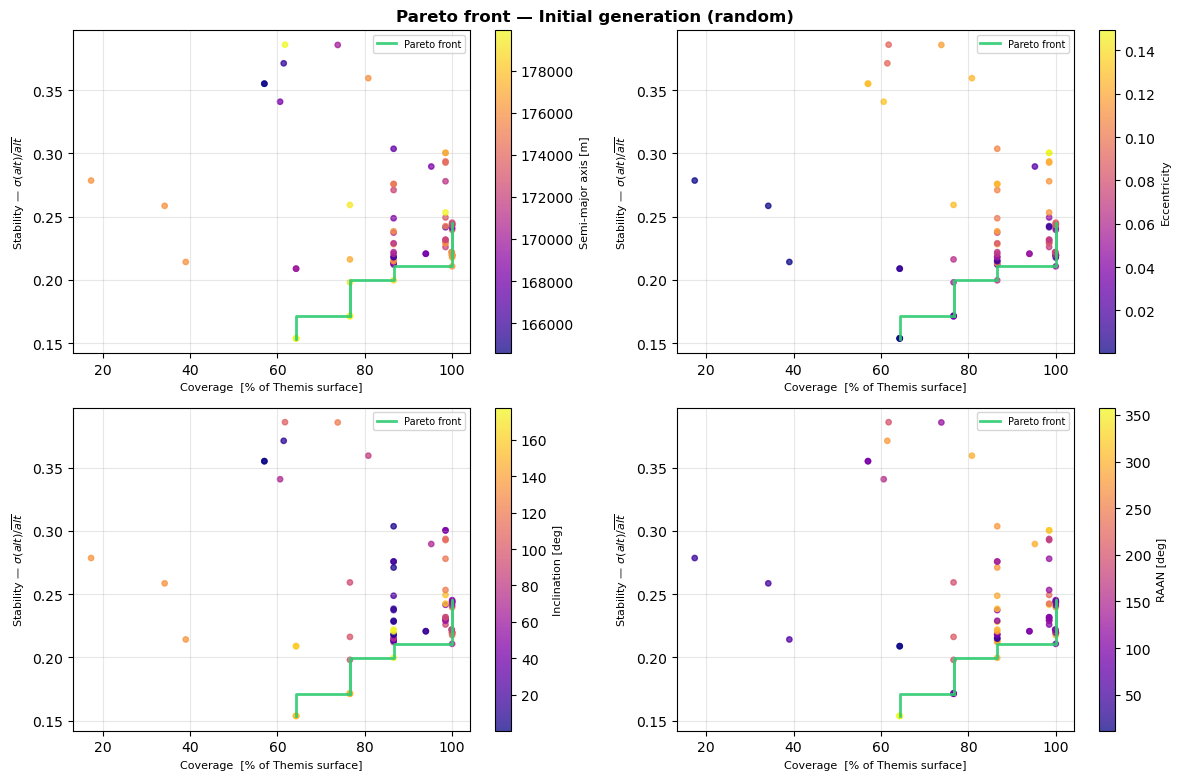

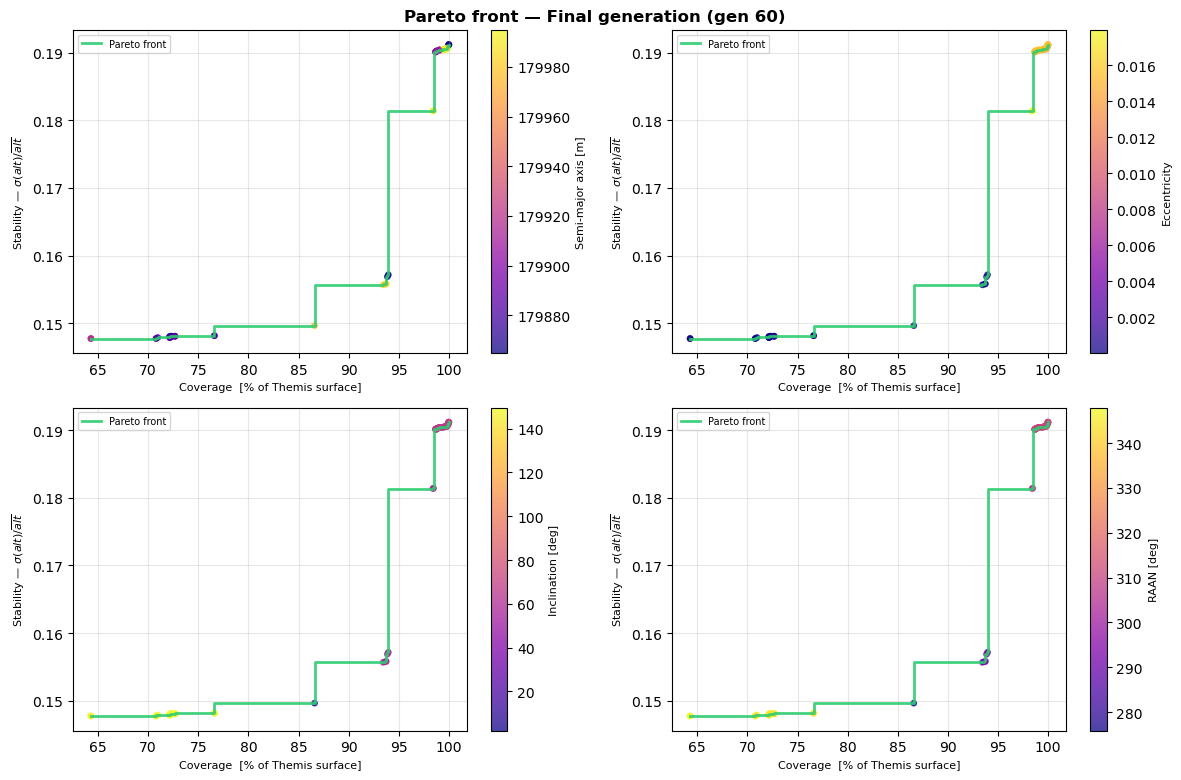

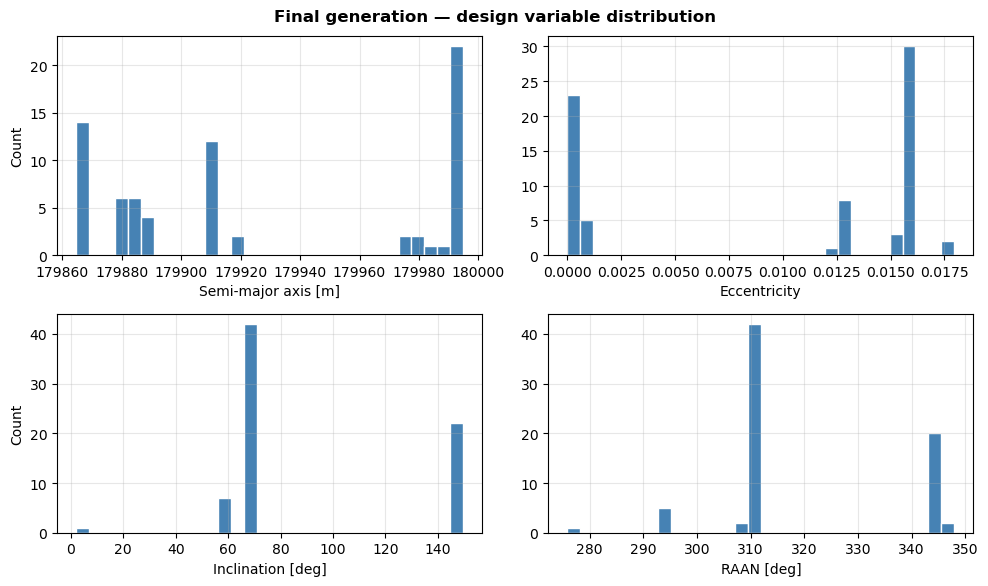

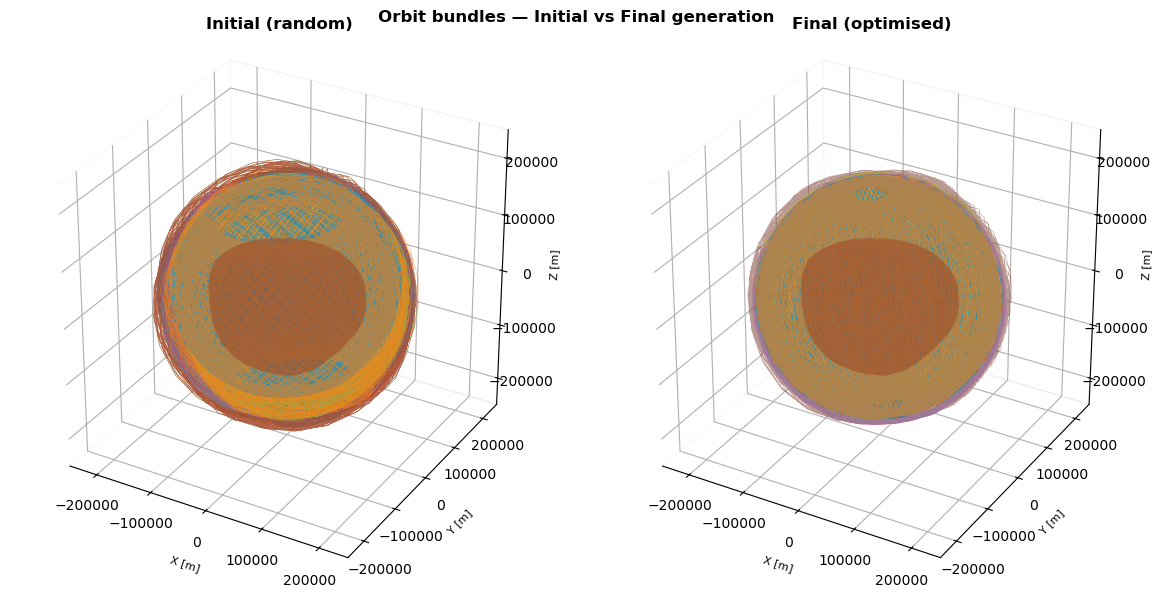


── Knee-point (best trade-off) orbit ───────────────────────────────
  Coverage (area/total)       : 93.76%
  Stability σ(alt)/mean(alt)  : 1.5582e-01
  Semi-major axis             : 179.981 km
  Eccentricity                : 0.00009
  Inclination                 : 56.52 deg
  RAAN                        : 292.86 deg
────────────────────────────────────────────────────────────────────

── Best-coverage orbit ─────────────────────────────────────────────
  Coverage                    : 100.00%
  Stability σ(alt)/mean(alt)  : 1.9120e-01
  Semi-major axis             : 179.865 km
  Eccentricity                : 0.01568
  Inclination                 : 68.38 deg
  RAAN                        : 311.21 deg
────────────────────────────────────────────────────────────────────

── Full Pareto front (sorted by coverage, high → low) ──────────────────
Rank    Coverage     σ(alt)/alt̄     a [km]        e    i [°]    Ω [°]
   1     100.00%      1.9120e-01    179.865  0.01568    68.38   311.21 ← BES

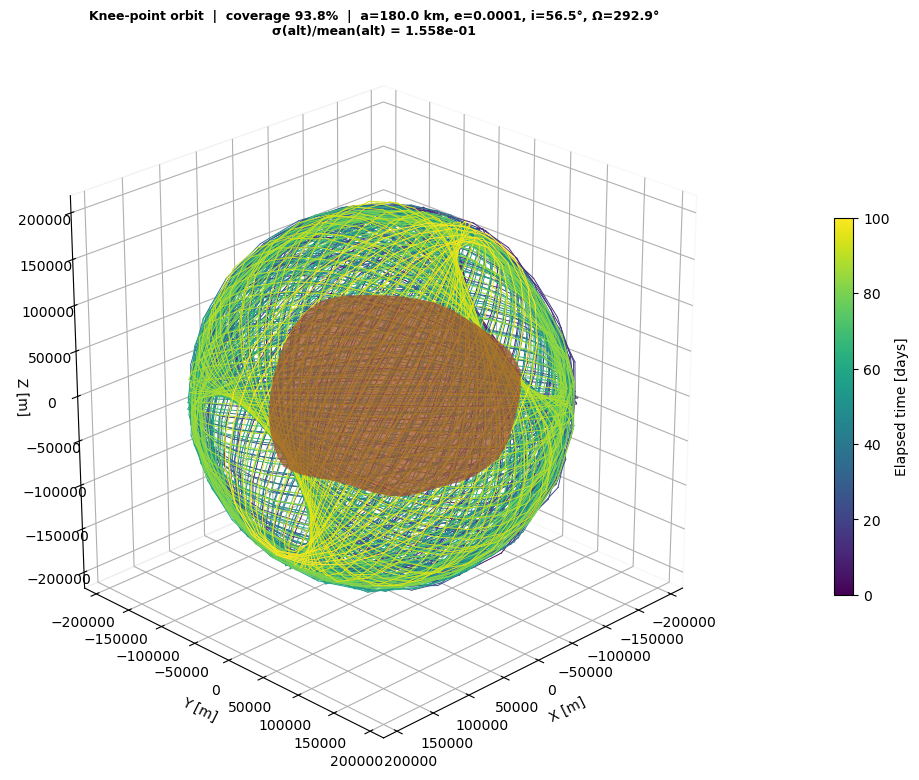

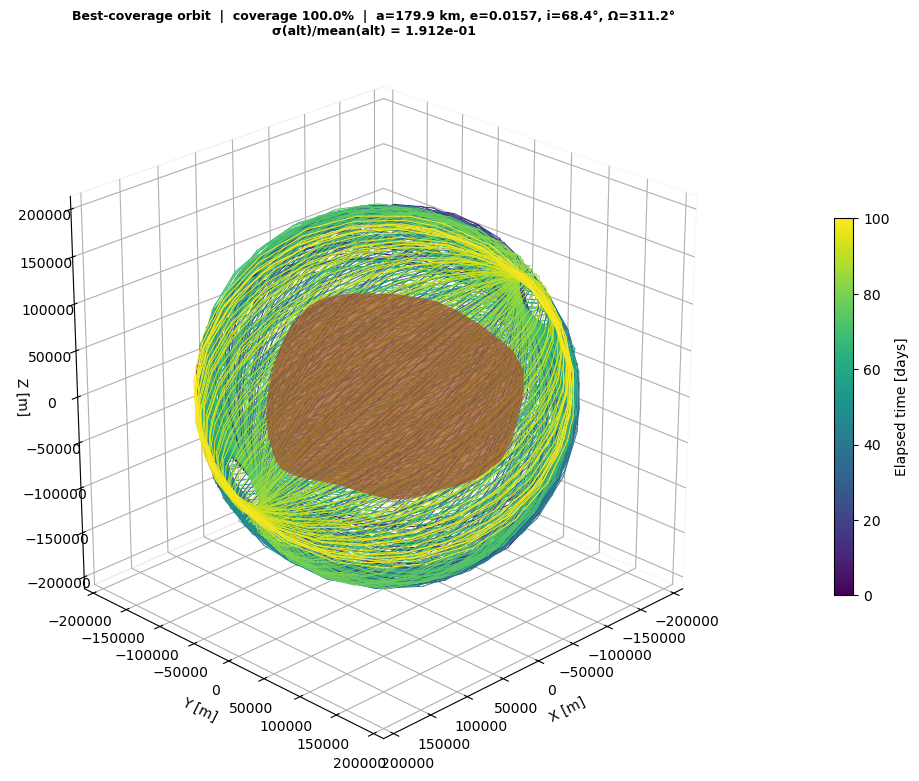

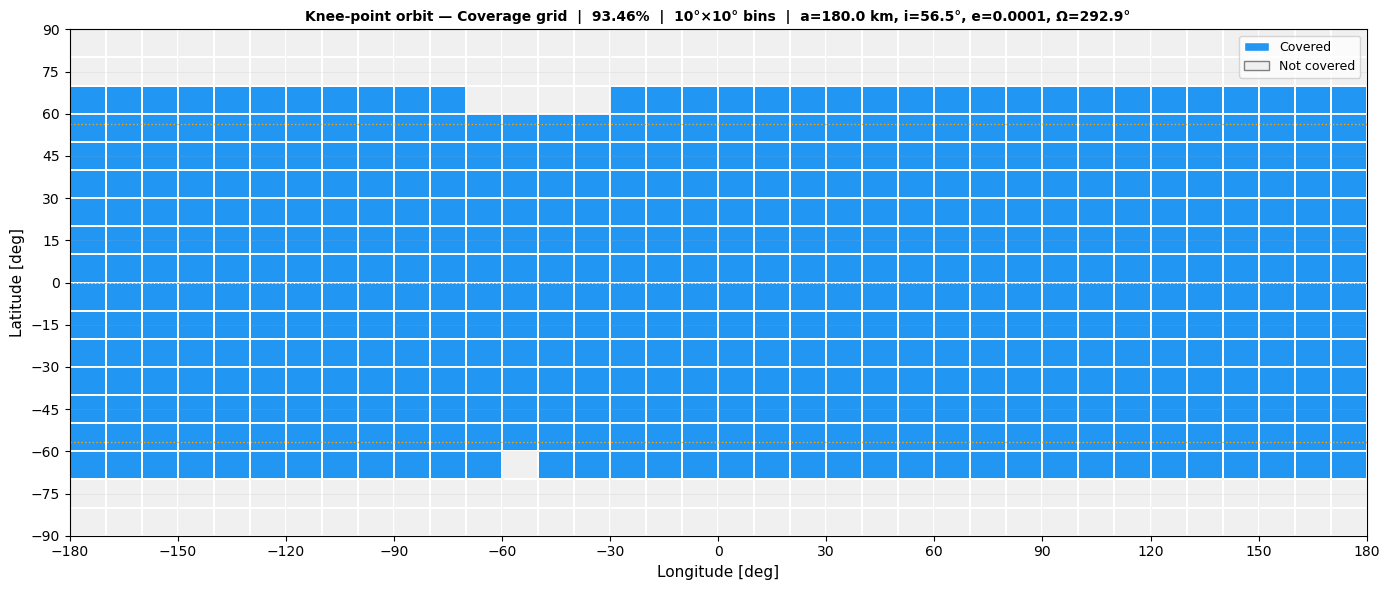

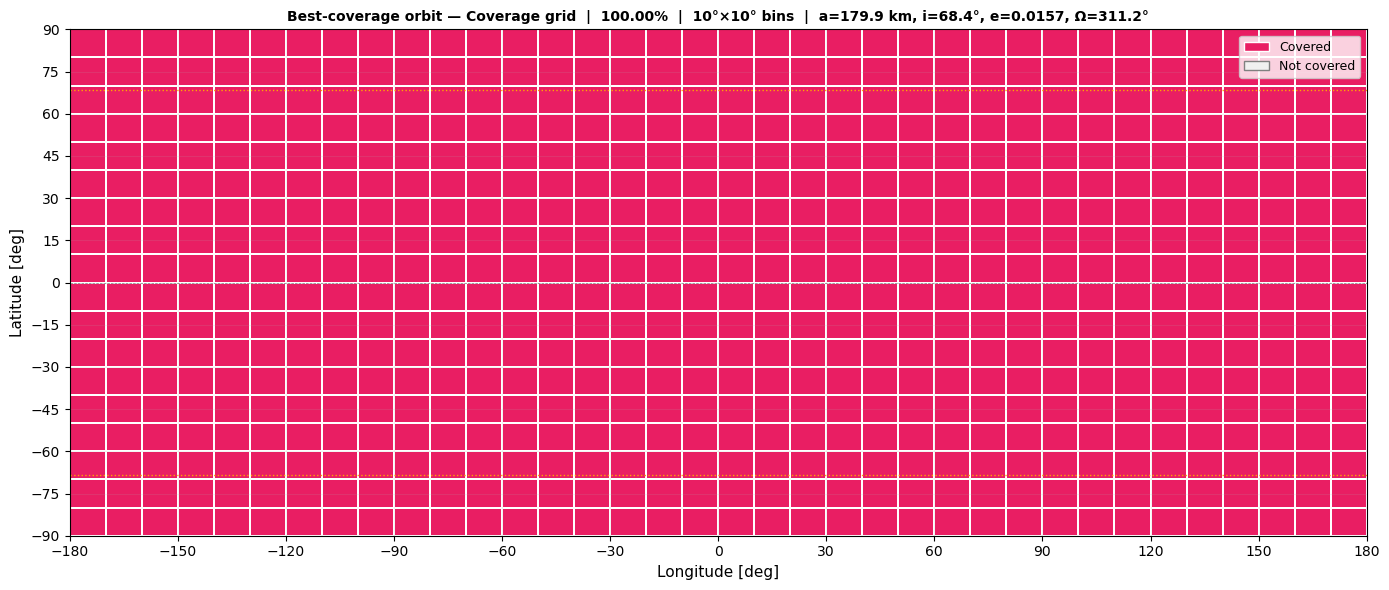

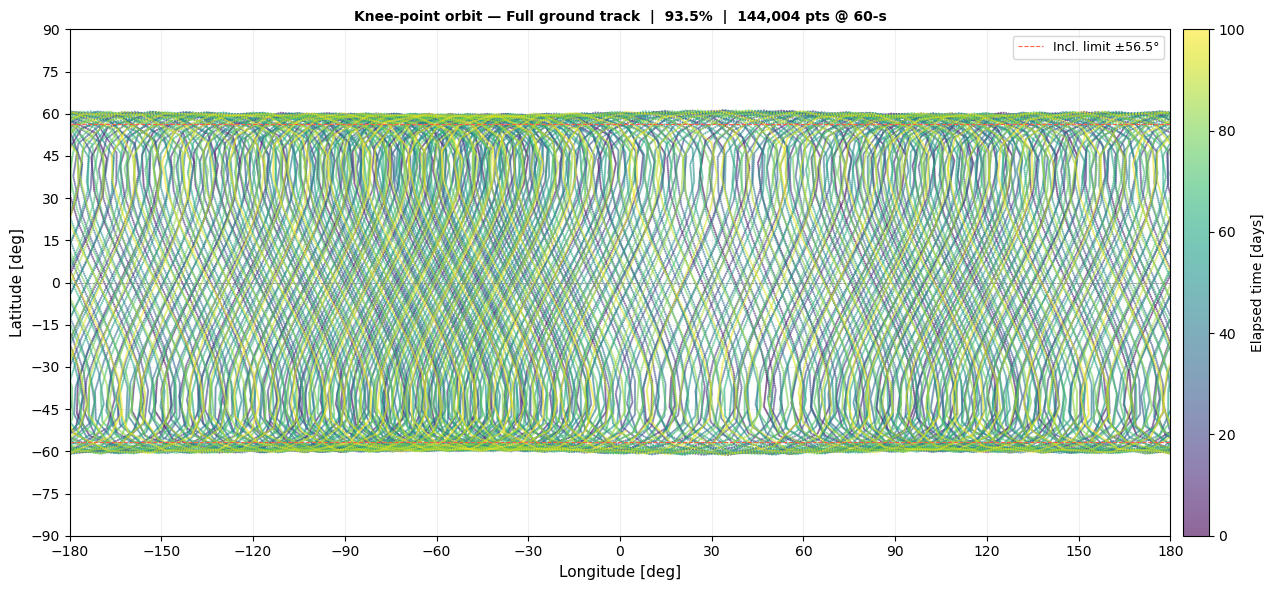

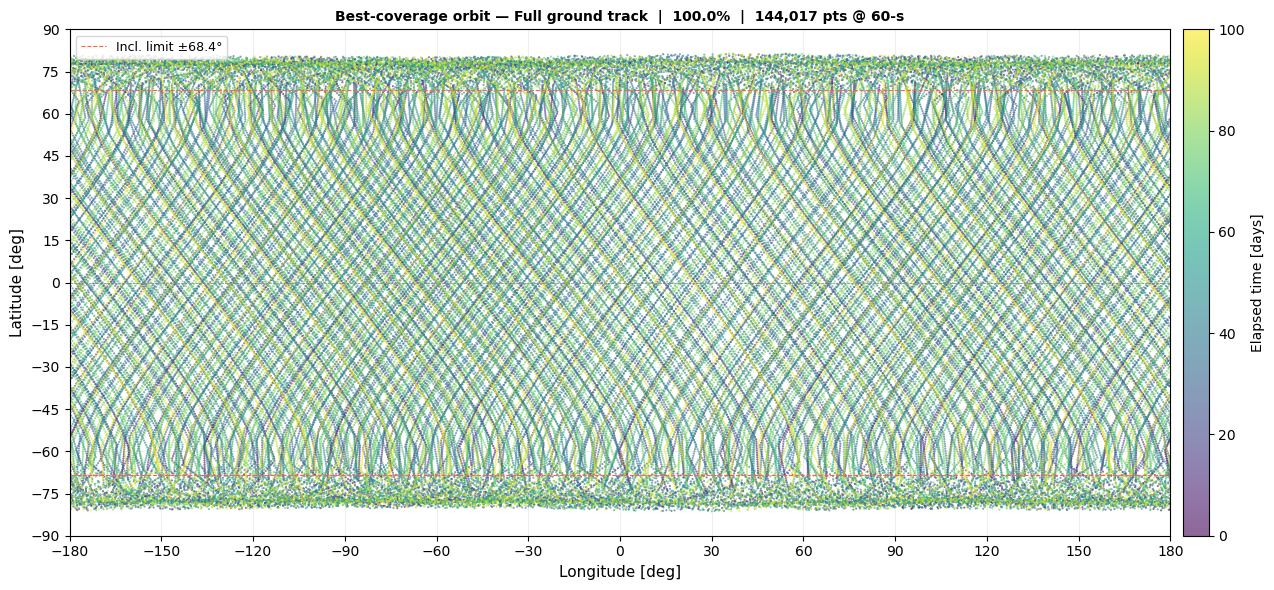

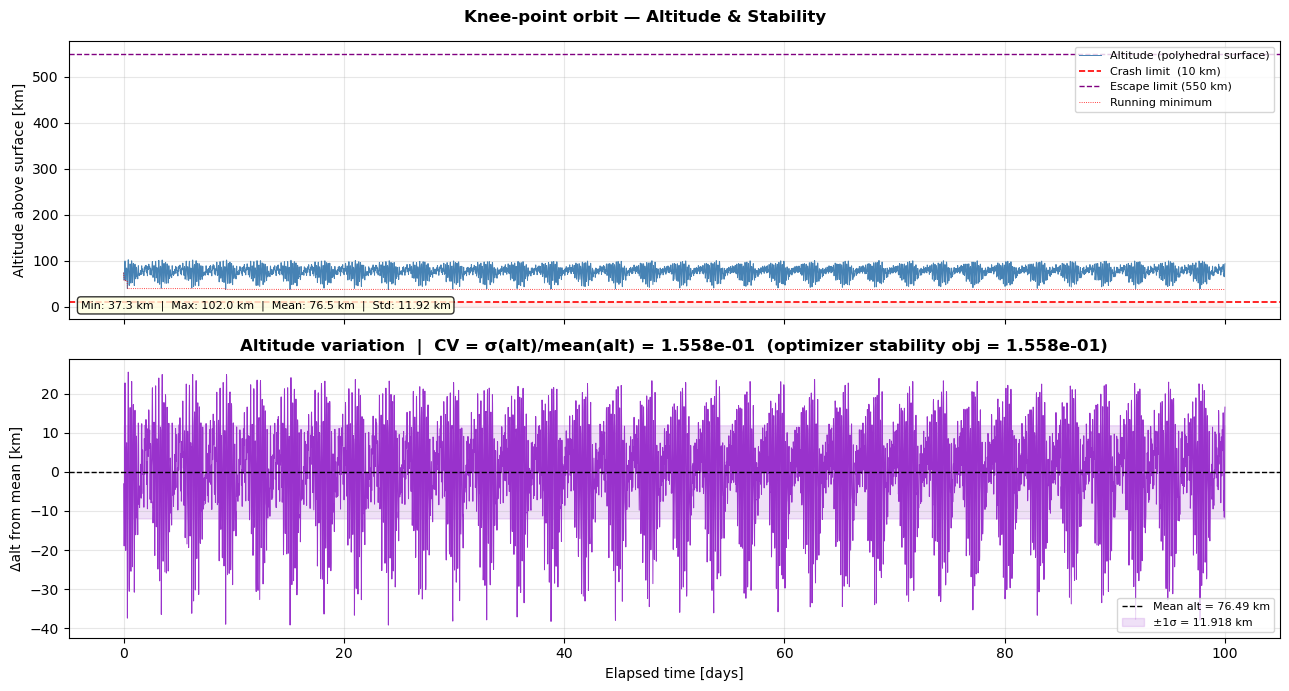

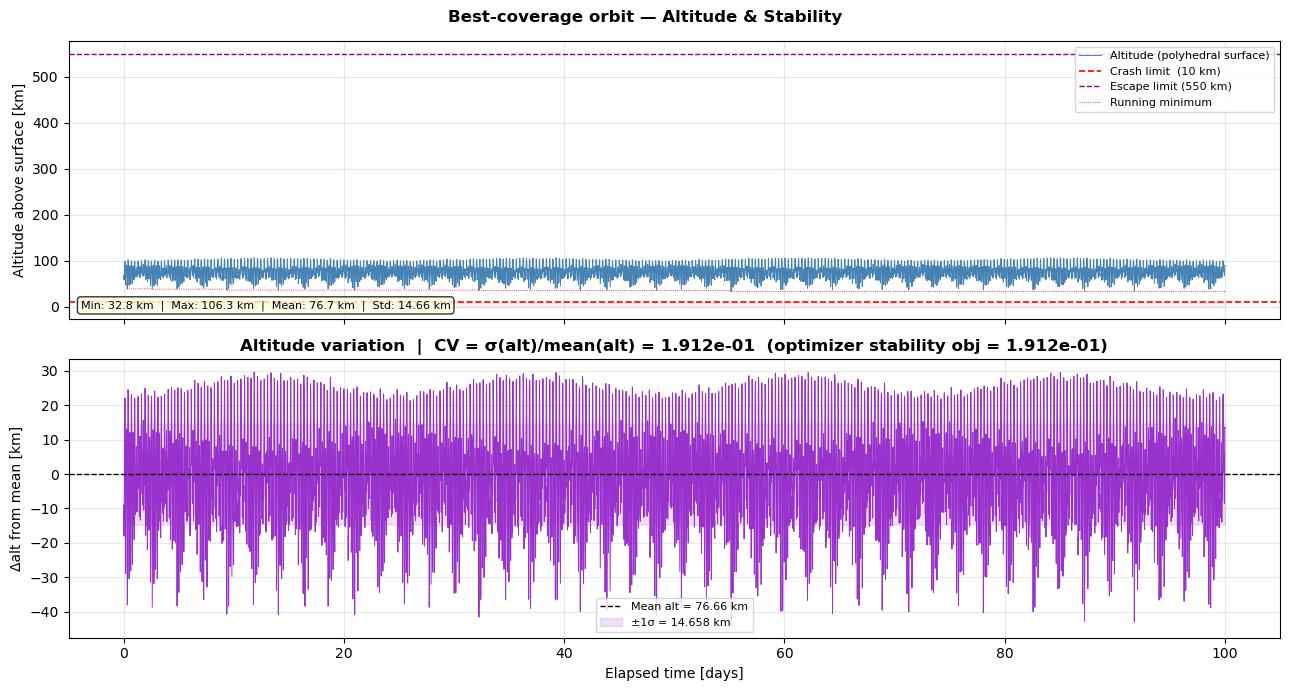

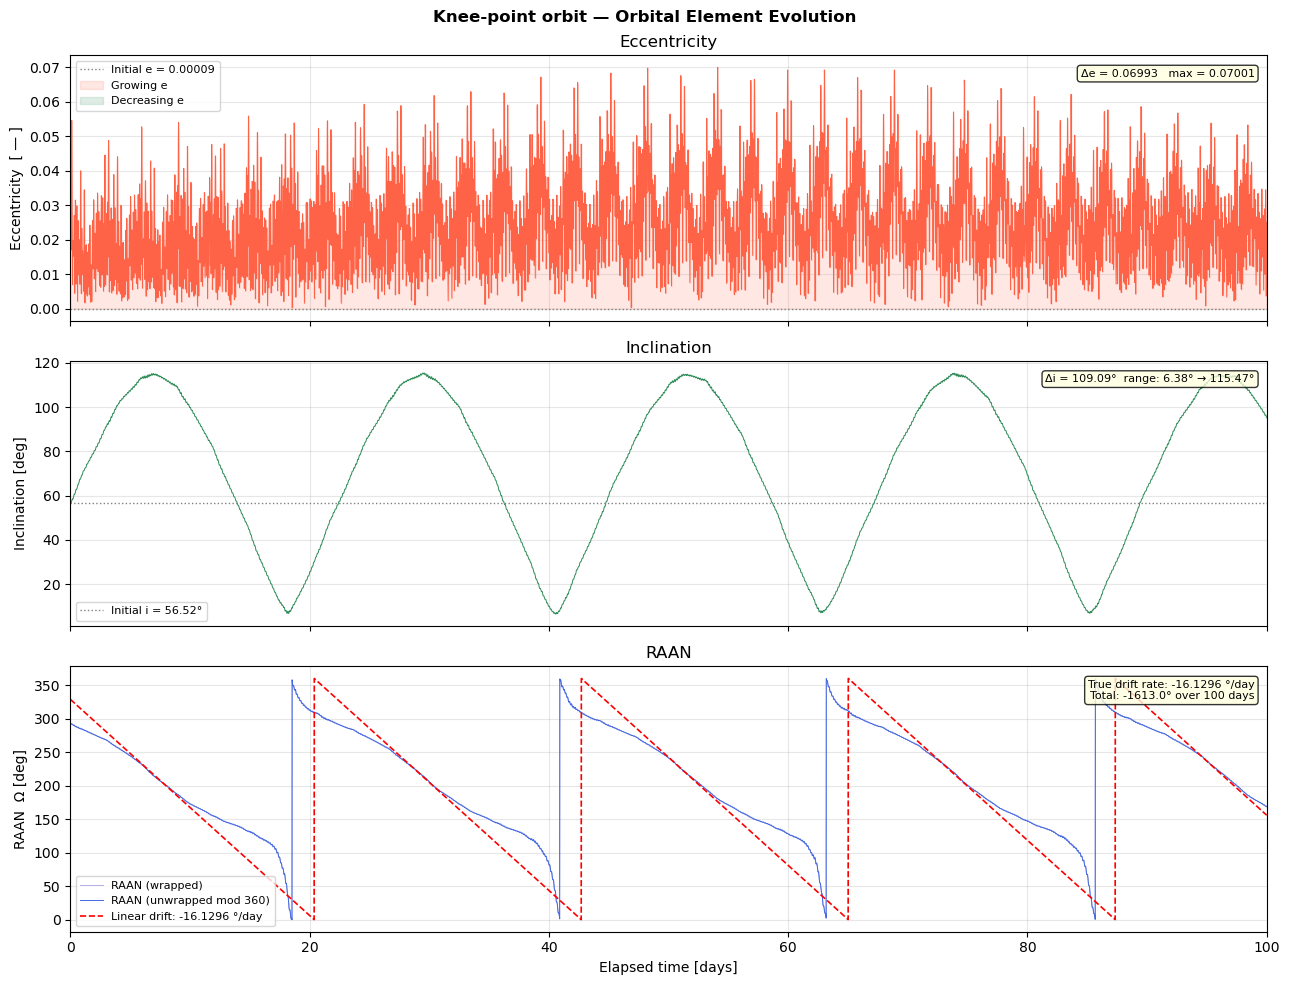

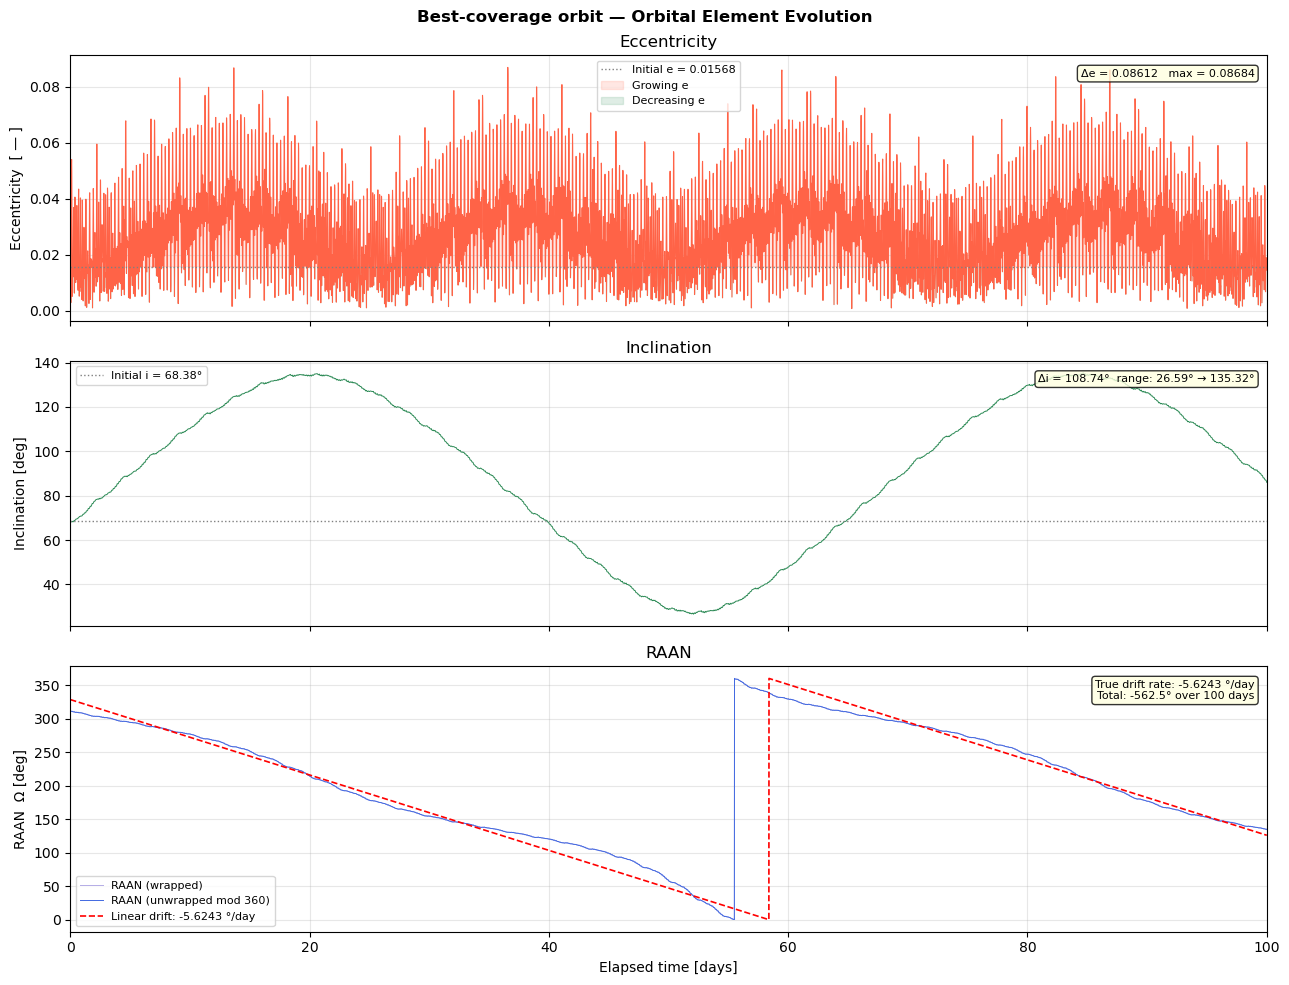

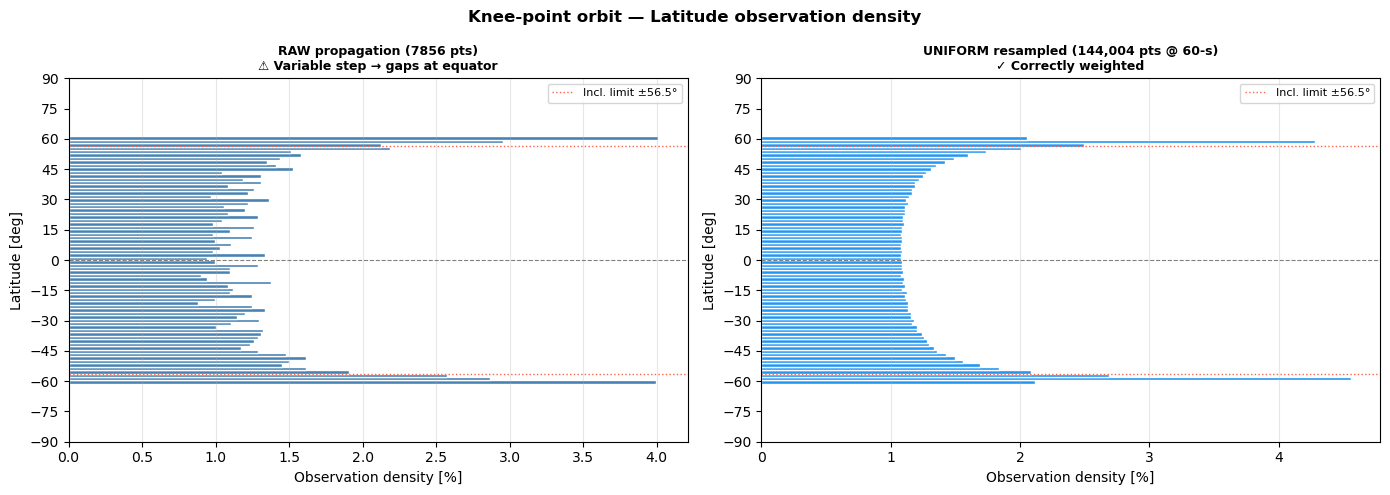

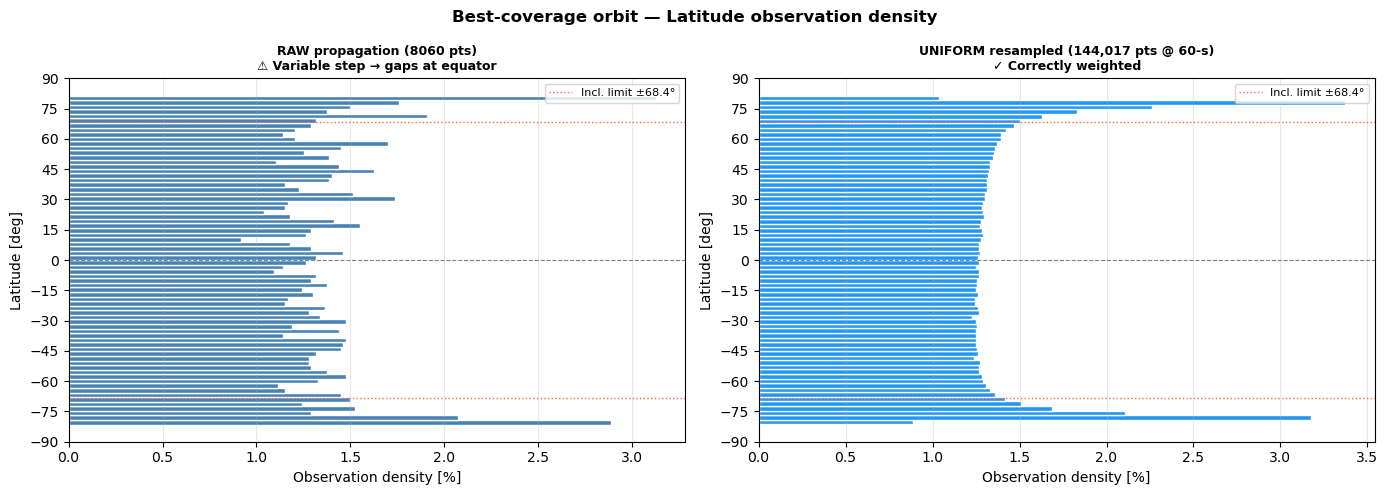

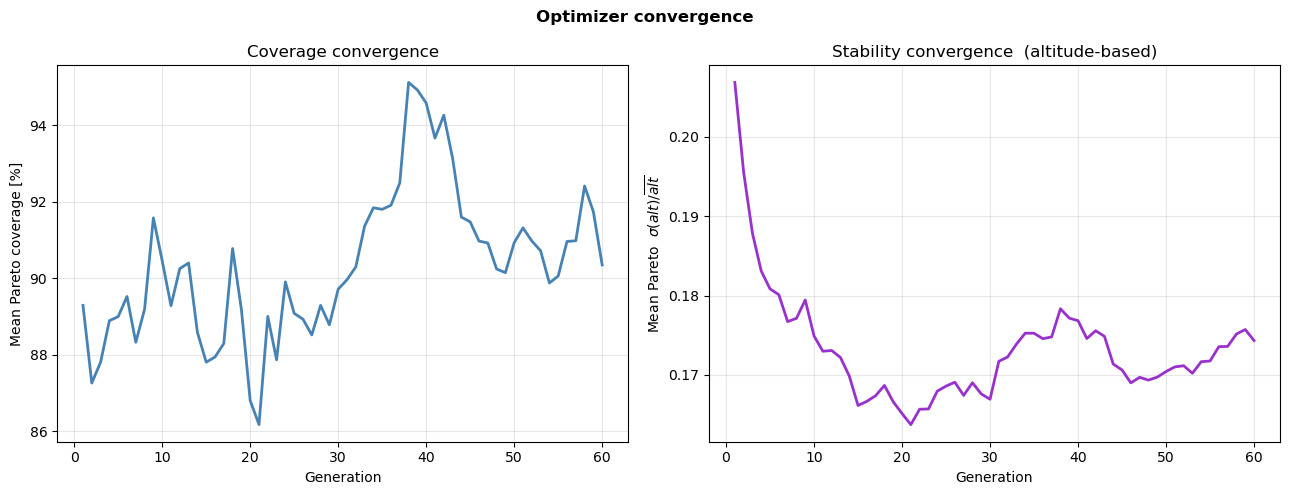

[SAVE] Knee-point orbit: 7856 pts → D:\CALTECH_MS_SPACE_ENGINEERING\105c\knee_point_trajectory.csv
[SAVE] Best-coverage orbit: 8060 pts → D:\CALTECH_MS_SPACE_ENGINEERING\105c\best_coverage_trajectory.csv

═════════════════════════════════════════════════════════════════
  KNEE-POINT ORBIT SUMMARY
═════════════════════════════════════════════════════════════════
  Semi-major axis          : 179.981 km
  Eccentricity             : 0.00009
  Inclination              : 56.52 deg
  RAAN                     : 292.86 deg
  Coverage                 : 93.46%
  σ(alt)/mean(alt)         : 1.5582e-01
  Alt — min / mean / max   : 37.32 / 76.49 / 101.99 km
  Alt std dev              : 11.918 km
  Survival                 : 100.00 / 100 days
═════════════════════════════════════════════════════════════════
  BEST-COVERAGE ORBIT SUMMARY
═════════════════════════════════════════════════════════════════
  Semi-major axis          : 179.865 km
  Eccentricity             : 0.01568
  Inclination           

In [19]:
# =============================================================================
# THEMIS ORBIT OPTIMIZATION — COMPLETE POST-PROCESSING
# =============================================================================
# Column map for dep_arr (must match get_dependent_variables_to_save order):
#   col 0  = spherical r = dist from CoM  [m]
#   col 1  = latitude                     [rad]
#   col 2  = longitude                    [rad]
#   col 3  = semi-major axis              [m]
#   col 4  = eccentricity                 [-]
#   col 5  = inclination                  [rad]
#   col 6  = argument of periapsis        [rad]
#   col 7  = RAAN                         [rad]
#   col 8  = true anomaly                 [rad]
#   col 9  = TRUE altitude above surface  [m]   ← polyhedral shape model
#   col 10 = distance from CoM            [m]
# =============================================================================

import numpy as np
import csv
import os
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.interpolate import interp1d
import tudatpy.util as util

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def add_themis_polyhedron(ax, vertices, faces, alpha=0.5, facecolor='sienna',
                           edgecolor='peru', linewidth=0.05):
    """Render actual polyhedral Themis mesh on a 3D axis."""
    poly_verts = vertices[faces]
    mesh = Poly3DCollection(poly_verts, alpha=alpha,
                             facecolor=facecolor, edgecolor=edgecolor,
                             linewidth=linewidth)
    ax.add_collection3d(mesh)
    return mesh


def resample_uniform(times_s, lat_deg, lon_deg, dt_seconds=60.0):
    """
    Interpolate lat/lon to uniformly spaced time steps.
    Fixes the variable-step RKF integrator bias — equator crossings get
    fewer raw points, causing histogram gaps if raw points are used directly.
    """
    t_u = np.arange(times_s[0], times_s[-1], dt_seconds)
    f_lat = interp1d(times_s, lat_deg, kind='linear', fill_value='extrapolate')
    lat_u = f_lat(t_u)
    lon_unwrapped = np.unwrap(np.deg2rad(lon_deg))
    f_lon = interp1d(times_s, lon_unwrapped, kind='linear', fill_value='extrapolate')
    lon_u = np.rad2deg(f_lon(t_u)) % 360
    lon_u = np.where(lon_u > 180, lon_u - 360, lon_u)
    return t_u, lat_u, lon_u


def compute_coverage(lat_deg, lon_deg, orbitProblem):
    """Compute fractional coverage using orbitProblem grid cell areas."""
    lat_r = np.deg2rad(lat_deg)
    lon_r = np.deg2rad(lon_deg)
    lat_idx = np.clip(np.searchsorted(orbitProblem.lat_edges[1:], lat_r),
                      0, orbitProblem.lat_bins - 1)
    lon_idx = np.clip(np.searchsorted(orbitProblem.lon_edges[1:], lon_r),
                      0, orbitProblem.lon_bins - 1)
    grid = np.zeros((orbitProblem.lat_bins, orbitProblem.lon_bins), dtype=bool)
    grid[lat_idx, lon_idx] = True
    return np.sum(orbitProblem.cell_areas[grid]) / orbitProblem.total_surface, grid


# =============================================================================
# SECTION 1 — PARETO FRONT PLOTS (initial and final generation)
# =============================================================================
design_variable_names = {
    0: 'Semi-major axis [m]',
    1: 'Eccentricity',
    2: 'Inclination [deg]',
    3: 'RAAN [deg]'
}

for population_index in simulation_output.keys():
    current_generation = simulation_output[population_index]
    current_fitness    = current_generation[1]
    current_population = current_generation[2]

    gen_label = 'Initial generation (random)' \
        if population_index == 0 \
        else f'Final generation (gen {number_of_evolutions})'

    coverage_pct = (1.0 - current_fitness[:, 0]) * 100
    stability_cv = current_fitness[:, 1]   # now σ(alt)/mean(alt)

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'Pareto front — {gen_label}', fontweight='bold', y=0.97)

    for ax_index, ax in enumerate(axs.flatten()):
        cs = ax.scatter(coverage_pct, stability_cv,
                        c=current_population[:, ax_index],
                        s=60, marker='.', cmap='plasma', alpha=0.75)
        cbar = fig.colorbar(cs, ax=ax)
        cbar.ax.set_ylabel(design_variable_names[ax_index], fontsize=8)

        pareto_mask_p = util.pareto_optimums(current_fitness)
        pareto_cov    = coverage_pct[pareto_mask_p]
        pareto_sta    = stability_cv[pareto_mask_p]
        sort_idx      = np.argsort(pareto_cov)
        ax.step(pareto_cov[sort_idx], pareto_sta[sort_idx],
                color='#2ecc71', linewidth=2, alpha=0.9, label='Pareto front')

        ax.set_xlabel('Coverage  [% of Themis surface]', fontsize=8)
        ax.set_ylabel(r'Stability — $\sigma(alt) / \overline{alt}$', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(f'pareto_front_{gen_label[:5].strip()}.png', dpi=130,
                bbox_inches='tight')
    plt.show()


# =============================================================================
# SECTION 2 — DESIGN VARIABLE HISTOGRAMS (final generation)
# =============================================================================
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle('Final generation — design variable distribution',
             fontweight='bold', y=0.97)
last_pop = simulation_output[number_of_evolutions - 1][2]

for ax_index, ax in enumerate(axs.flatten()):
    ax.hist(last_pop[:, ax_index], bins=30, color='steelblue', edgecolor='white')
    ax.set_xlabel(design_variable_names[ax_index])
    if ax_index % 2 == 0:
        ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('design_variable_histogram.png', dpi=130, bbox_inches='tight')
plt.show()


# =============================================================================
# SECTION 3 — ORBIT BUNDLES (initial vs final, with polyhedral Themis)
# =============================================================================
PLOT_LIM = 250_000   # metres — set to 1.4 × max orbit radius

fig = plt.figure(figsize=(12, 6))
fig.suptitle('Orbit bundles — Initial vs Final generation',
             fontweight='bold', y=0.97)
title_map = {0: 'Initial (random)', 1: 'Final (optimised)'}

for ax_index, population_index in enumerate(simulation_output.keys()):
    ax3d = fig.add_subplot(1, 2, 1 + ax_index, projection='3d')
    ax3d.set_facecolor('white')
    ax3d.xaxis.pane.fill = False
    ax3d.yaxis.pane.fill = False
    ax3d.zaxis.pane.fill = False

    # Polyhedral Themis
    add_themis_polyhedron(ax3d, themis_vertices, themis_faces, alpha=0.45)

    current_gen = simulation_output[population_index]
    for ind_index in range(len(current_gen[2])):
        sh = np.vstack(list(current_gen[0][ind_index][0].values()))
        ax3d.plot(sh[:, 0], sh[:, 1], sh[:, 2], linewidth=0.4, alpha=0.6)

    ax3d.set_xlim(-PLOT_LIM, PLOT_LIM)
    ax3d.set_ylim(-PLOT_LIM, PLOT_LIM)
    ax3d.set_zlim(-PLOT_LIM, PLOT_LIM)
    ax3d.set_xlabel('X [m]', fontsize=8)
    ax3d.set_ylabel('Y [m]', fontsize=8)
    ax3d.set_zlabel('Z [m]', fontsize=8)
    ax3d.set_box_aspect([1, 1, 1])
    ax3d.set_title(title_map[ax_index], fontweight='bold')

plt.tight_layout()
plt.savefig('orbit_bundles.png', dpi=130, bbox_inches='tight')
plt.show()


# =============================================================================
# SECTION 4 — KNEE-POINT SELECTION
# =============================================================================
final_fitness    = fitness_list[-1]
final_population = population_list[-1]

pareto_mask    = util.pareto_optimums(final_fitness)
pareto_fitness = final_fitness[pareto_mask]
pareto_params  = final_population[pareto_mask]

obj_min   = pareto_fitness.min(axis=0)
obj_max   = pareto_fitness.max(axis=0)
obj_range = obj_max - obj_min + 1e-12

pareto_normalised = (pareto_fitness - obj_min) / obj_range
dist_to_ideal     = np.linalg.norm(pareto_normalised, axis=1)
knee_idx          = np.argmin(dist_to_ideal)

best_params       = pareto_params[knee_idx]
best_fitness      = pareto_fitness[knee_idx]
best_coverage_pct = (1.0 - best_fitness[0]) * 100
best_stability_cv = best_fitness[1]   # σ(alt)/mean(alt)

print("\n── Knee-point (best trade-off) orbit ───────────────────────────────")
print(f"  Coverage (area/total)       : {best_coverage_pct:.2f}%")
print(f"  Stability σ(alt)/mean(alt)  : {best_stability_cv:.4e}")
print(f"  Semi-major axis             : {best_params[0]/1e3:.3f} km")
print(f"  Eccentricity                : {best_params[1]:.5f}")
print(f"  Inclination                 : {best_params[2]:.2f} deg")
print(f"  RAAN                        : {best_params[3]:.2f} deg")
print("────────────────────────────────────────────────────────────────────")


# =============================================================================
# SECTION 5 — BEST COVERAGE ORBIT SELECTION
# =============================================================================
pareto_mask_bc  = util.pareto_optimums(final_fitness)
pareto_fit_bc   = final_fitness[pareto_mask_bc]
pareto_par_bc   = final_population[pareto_mask_bc]

best_cov_idx    = np.argmin(pareto_fit_bc[:, 0])
bc_params       = pareto_par_bc[best_cov_idx]
bc_fitness      = pareto_fit_bc[best_cov_idx]
bc_coverage_pct = (1.0 - bc_fitness[0]) * 100
bc_stability_cv = bc_fitness[1]

print("\n── Best-coverage orbit ─────────────────────────────────────────────")
print(f"  Coverage                    : {bc_coverage_pct:.2f}%")
print(f"  Stability σ(alt)/mean(alt)  : {bc_stability_cv:.4e}")
print(f"  Semi-major axis             : {bc_params[0]/1e3:.3f} km")
print(f"  Eccentricity                : {bc_params[1]:.5f}")
print(f"  Inclination                 : {bc_params[2]:.2f} deg")
print(f"  RAAN                        : {bc_params[3]:.2f} deg")
print("────────────────────────────────────────────────────────────────────")

# Full Pareto table
print("\n── Full Pareto front (sorted by coverage, high → low) ──────────────────")
print(f"{'Rank':>4}  {'Coverage':>10}  {'σ(alt)/alt̄':>14}  "
      f"{'a [km]':>9}  {'e':>7}  {'i [°]':>7}  {'Ω [°]':>7}")
sort_cov = np.argsort(pareto_fit_bc[:, 0])
for rank, idx in enumerate(sort_cov):
    marker = ' ← BEST COV' if idx == best_cov_idx else \
             ' ← KNEE'     if np.allclose(pareto_par_bc[idx],
                                           best_params, rtol=1e-4) else ''
    print(f"{rank+1:>4}  "
          f"{(1-pareto_fit_bc[idx,0])*100:>9.2f}%  "
          f"{pareto_fit_bc[idx,1]:>14.4e}  "
          f"{pareto_par_bc[idx,0]/1e3:>9.3f}  "
          f"{pareto_par_bc[idx,1]:>7.5f}  "
          f"{pareto_par_bc[idx,2]:>7.2f}  "
          f"{pareto_par_bc[idx,3]:>7.2f}{marker}")


# =============================================================================
# SECTION 6 — PROPAGATE BOTH BEST ORBITS
# =============================================================================
def propagate_and_extract(params, label):
    print(f"\nPropagating {label} orbit...")
    orbitProblem.fitness(params)
    sim       = orbitProblem.get_last_run_dynamics_simulator()
    state_h   = sim.propagation_results.state_history
    dep_h     = sim.propagation_results.dependent_variable_history

    states    = np.vstack(list(state_h.values()))
    dep       = np.vstack(list(dep_h.values()))
    times_s   = np.array(list(dep_h.keys()))
    times_d   = (times_s - mission_initial_time) / 86400.0

    # ── Extract using correct column indices ──────────────────────────────────
    lat_deg   = np.rad2deg(dep[:, 1])
    lon_deg   = np.rad2deg(dep[:, 2])
    sma_km    = dep[:, 3] / 1e3
    ecc       = dep[:, 4]
    inc_deg   = np.rad2deg(dep[:, 5])
    aop_deg   = np.rad2deg(dep[:, 6])
    raan_deg  = np.rad2deg(dep[:, 7])
    alt_km    = dep[:, 9] / 1e3      # col 9 = TRUE altitude above polyhedral surface
    dist_km   = dep[:, 10] / 1e3     # col 10 = CoM distance

    return {
        'states': states, 'dep': dep, 'state_h': state_h, 'dep_h': dep_h,
        'times_s': times_s, 'times_d': times_d,
        'lat_deg': lat_deg, 'lon_deg': lon_deg,
        'sma_km': sma_km, 'ecc': ecc, 'inc_deg': inc_deg,
        'aop_deg': aop_deg, 'raan_deg': raan_deg,
        'alt_km': alt_km, 'dist_km': dist_km
    }


knee = propagate_and_extract(best_params, 'knee-point')
bc   = propagate_and_extract(bc_params,   'best-coverage')

# Resample both to uniform 60-s steps
_, knee['lat_u'], knee['lon_u'] = resample_uniform(
    knee['times_s'], knee['lat_deg'], knee['lon_deg'])
knee['t_u'] = np.arange(knee['times_s'][0], knee['times_s'][-1], 60.0)
knee['td_u'] = (knee['t_u'] - mission_initial_time) / 86400.0

_, bc['lat_u'], bc['lon_u'] = resample_uniform(
    bc['times_s'], bc['lat_deg'], bc['lon_deg'])
bc['t_u'] = np.arange(bc['times_s'][0], bc['times_s'][-1], 60.0)
bc['td_u'] = (bc['t_u'] - mission_initial_time) / 86400.0

# Coverage grids
knee_cov_frac, knee_grid = compute_coverage(
    knee['lat_u'], knee['lon_u'], orbitProblem)
bc_cov_frac, bc_grid = compute_coverage(
    bc['lat_u'], bc['lon_u'], orbitProblem)

print(f"\n[COVERAGE] Knee-point (resampled): {knee_cov_frac*100:.2f}%")
print(f"[COVERAGE] Best-coverage (resampled): {bc_cov_frac*100:.2f}%")

lat_edges_deg = np.rad2deg(orbitProblem.lat_edges)
lon_edges_deg = np.rad2deg(orbitProblem.lon_edges)
lat_bins      = orbitProblem.lat_bins
lon_bins      = orbitProblem.lon_bins


# =============================================================================
# SECTION 7 — 3D TRAJECTORY PLOTS  (polyhedral Themis)
# =============================================================================
def plot_3d_trajectory(data, params, label, coverage_pct, stability_cv):
    fig = plt.figure(figsize=(10, 8))
    ax3d = fig.add_subplot(1, 1, 1, projection='3d')
    ax3d.set_facecolor('white')
    ax3d.xaxis.pane.fill = False
    ax3d.yaxis.pane.fill = False
    ax3d.zaxis.pane.fill = False

    # Polyhedral Themis mesh
    add_themis_polyhedron(ax3d, themis_vertices, themis_faces, alpha=0.5)

    # Trajectory coloured by time
    n_pts  = len(data['states'])
    colors = plt.cm.viridis(np.linspace(0, 1, n_pts))
    for k in range(n_pts - 1):
        ax3d.plot(data['states'][k:k+2, 0],
                  data['states'][k:k+2, 1],
                  data['states'][k:k+2, 2],
                  color=colors[k], linewidth=0.7)

    sm = plt.cm.ScalarMappable(cmap='viridis',
                                norm=plt.Normalize(0, data['times_d'][-1]))
    sm.set_array([])
    fig.colorbar(sm, ax=ax3d, shrink=0.5, label='Elapsed time [days]', pad=0.1)

    lim = max(np.abs(data['states'][:, :3]).max() * 1.1, 200_000)
    ax3d.set_xlim(-lim, lim);  ax3d.set_xlabel('X [m]')
    ax3d.set_ylim(-lim, lim);  ax3d.set_ylabel('Y [m]')
    ax3d.set_zlim(-lim, lim);  ax3d.set_zlabel('Z [m]')
    ax3d.set_box_aspect([1, 1, 1])
    ax3d.set_title(
        f'{label}  |  coverage {coverage_pct:.1f}%  |  '
        f'a={params[0]/1e3:.1f} km, e={params[1]:.4f}, '
        f'i={params[2]:.1f}°, Ω={params[3]:.1f}°\n'
        f'σ(alt)/mean(alt) = {stability_cv:.3e}',
        fontweight='bold', fontsize=9)
    ax3d.view_init(elev=25, azim=45)
    plt.tight_layout()
    plt.savefig(f'3d_trajectory_{label[:4].strip()}.png', dpi=130,
                bbox_inches='tight')
    plt.show()


plot_3d_trajectory(knee, best_params, 'Knee-point orbit',
                   best_coverage_pct, best_stability_cv)
plot_3d_trajectory(bc,   bc_params,   'Best-coverage orbit',
                   bc_coverage_pct,   bc_stability_cv)


# =============================================================================
# SECTION 8 — COVERAGE GRID PLOTS
# =============================================================================
def plot_coverage_grid(grid, params, label, coverage_pct, cov_color):
    fig, ax = plt.subplots(figsize=(14, 6))
    cmap_g = plt.cm.colors.ListedColormap(['#f0f0f0', cov_color])
    ax.pcolormesh(lon_edges_deg, lat_edges_deg, grid,
                  cmap=cmap_g, vmin=0, vmax=1,
                  edgecolors='white', linewidth=0.15)

    legend_els = [Patch(facecolor=cov_color, edgecolor='white', label='Covered'),
                  Patch(facecolor='#f0f0f0', edgecolor='grey',  label='Not covered')]
    ax.legend(handles=legend_els, fontsize=9, loc='upper right')

    ax.set_xlabel('Longitude [deg]', fontsize=11)
    ax.set_ylabel('Latitude [deg]', fontsize=11)
    ax.set_xlim(-180, 180);  ax.set_ylim(-90, 90)
    ax.set_xticks(np.arange(-180, 181, 30))
    ax.set_yticks(np.arange(-90,   91, 15))
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.axhline( params[2], color='orange', linewidth=1.0, linestyle=':',
                label=f'±incl = ±{params[2]:.1f}°')
    ax.axhline(-params[2], color='orange', linewidth=1.0, linestyle=':')
    ax.grid(True, alpha=0.15)
    bin_deg = int(np.round(np.rad2deg(orbitProblem.lat_edges[1]
                                      - orbitProblem.lat_edges[0])))
    ax.set_title(f'{label} — Coverage grid  |  {coverage_pct:.2f}%  '
                 f'|  {bin_deg}°×{bin_deg}° bins  '
                 f'|  a={params[0]/1e3:.1f} km, i={params[2]:.1f}°, '
                 f'e={params[1]:.4f}, Ω={params[3]:.1f}°',
                 fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'coverage_grid_{label[:4].strip()}.png', dpi=130,
                bbox_inches='tight')
    plt.show()


plot_coverage_grid(knee_grid, best_params, 'Knee-point orbit',
                   knee_cov_frac*100, '#2196F3')
plot_coverage_grid(bc_grid,   bc_params,   'Best-coverage orbit',
                   bc_cov_frac*100,   '#E91E63')


# =============================================================================
# SECTION 9 — FULL GROUND TRACK PLOTS
# =============================================================================
def plot_ground_track(data, params, label, coverage_pct):
    fig, ax = plt.subplots(figsize=(14, 6))
    sc = ax.scatter(data['lon_u'], data['lat_u'],
                    c=data['td_u'][:len(data['lon_u'])],
                    cmap='viridis', s=0.3, alpha=0.6, rasterized=True)
    fig.colorbar(sc, ax=ax, pad=0.01, label='Elapsed time [days]')
    ax.axhline( params[2], color='tomato', linewidth=0.8, linestyle='--',
                label=f'Incl. limit ±{params[2]:.1f}°')
    ax.axhline(-params[2], color='tomato', linewidth=0.8, linestyle='--')
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Longitude [deg]', fontsize=11)
    ax.set_ylabel('Latitude [deg]', fontsize=11)
    ax.set_xlim(-180, 180);  ax.set_ylim(-90, 90)
    ax.set_xticks(np.arange(-180, 181, 30))
    ax.set_yticks(np.arange(-90, 91, 15))
    ax.legend(fontsize=9);  ax.grid(True, alpha=0.2)
    ax.set_title(f'{label} — Full ground track  |  {coverage_pct:.1f}%  '
                 f'|  {len(data["lon_u"]):,} pts @ 60-s',
                 fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'ground_track_{label[:4].strip()}.png', dpi=130,
                bbox_inches='tight')
    plt.show()


plot_ground_track(knee, best_params, 'Knee-point orbit', knee_cov_frac*100)
plot_ground_track(bc,   bc_params,   'Best-coverage orbit', bc_cov_frac*100)


# =============================================================================
# SECTION 10 — ALTITUDE vs TIME  (TRUE altitude from polyhedral shape, col 9)
# =============================================================================
def plot_altitude(data, params, label, stability_cv):
    alt_mean = np.mean(data['alt_km'])
    alt_std  = np.std(data['alt_km'])
    alt_cv   = alt_std / alt_mean
    alt_delta = data['alt_km'] - alt_mean

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    fig.suptitle(f'{label} — Altitude & Stability', fontweight='bold')

    # ── Top: altitude vs time ─────────────────────────────────────────────────
    axes[0].plot(data['times_d'], data['alt_km'],
                 color='steelblue', linewidth=0.7, label='Altitude (polyhedral surface)')
    axes[0].axhline(minimum_altitude/1e3, color='red',    ls='--', lw=1.2,
                    label=f'Crash limit  ({minimum_altitude/1e3:.0f} km)')
    axes[0].axhline(maximum_altitude/1e3, color='purple', ls='--', lw=1.0,
                    label=f'Escape limit ({maximum_altitude/1e3:.0f} km)')
    axes[0].fill_between(data['times_d'], 0, minimum_altitude/1e3,
                         color='red', alpha=0.06)
    running_min = np.minimum.accumulate(data['alt_km'])
    axes[0].plot(data['times_d'], running_min, color='red', lw=0.6,
                 ls=':', label='Running minimum')
    axes[0].set_ylabel('Altitude above surface [km]')
    axes[0].legend(fontsize=8, loc='upper right')
    axes[0].grid(True, alpha=0.3)
    stats_txt = (f"Min: {data['alt_km'].min():.1f} km  |  "
                 f"Max: {data['alt_km'].max():.1f} km  |  "
                 f"Mean: {alt_mean:.1f} km  |  "
                 f"Std: {alt_std:.2f} km")
    axes[0].text(0.01, 0.04, stats_txt, transform=axes[0].transAxes,
                 fontsize=8,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # ── Bottom: altitude deviation (stability metric) ─────────────────────────
    axes[1].plot(data['times_d'], alt_delta, color='darkorchid', linewidth=0.7)
    axes[1].axhline(0, color='k', ls='--', lw=1,
                    label=f'Mean alt = {alt_mean:.2f} km')
    axes[1].fill_between(data['times_d'], -alt_std, alt_std,
                         alpha=0.15, color='darkorchid',
                         label=f'±1σ = {alt_std:.3f} km')
    axes[1].set_xlabel('Elapsed time [days]')
    axes[1].set_ylabel('Δalt from mean [km]')
    axes[1].set_title(
        f'Altitude variation  |  CV = σ(alt)/mean(alt) = {alt_cv:.3e}  '
        f'(optimizer stability obj = {stability_cv:.3e})',
        fontweight='bold')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'altitude_{label[:4].strip()}.png', dpi=130, bbox_inches='tight')
    plt.show()
    return alt_mean, alt_std, alt_cv


knee_alt_mean, knee_alt_std, knee_alt_cv = plot_altitude(
    knee, best_params, 'Knee-point orbit', best_stability_cv)
bc_alt_mean, bc_alt_std, bc_alt_cv = plot_altitude(
    bc, bc_params, 'Best-coverage orbit', bc_stability_cv)


# =============================================================================
# SECTION 11 — ORBITAL ELEMENT EVOLUTION (e, i, RAAN)
# =============================================================================
def plot_orbital_elements(data, params, label):
    # Fix RAAN wrapping before fitting
    raan_unwrapped = np.rad2deg(np.unwrap(np.deg2rad(data['raan_deg'])))
    coeffs         = np.polyfit(data['times_d'], raan_unwrapped, 1)
    raan_fit       = np.polyval(coeffs, data['times_d'])

    fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
    fig.suptitle(f'{label} — Orbital Element Evolution', fontweight='bold')

    # Eccentricity
    axes[0].plot(data['times_d'], data['ecc'], color='tomato', linewidth=0.7)
    axes[0].axhline(data['ecc'][0], color='gray', ls=':', lw=1.0,
                    label=f'Initial e = {data["ecc"][0]:.5f}')
    axes[0].fill_between(data['times_d'], data['ecc'], data['ecc'][0],
                         where=(data['ecc'] > data['ecc'][0]),
                         color='tomato', alpha=0.15, label='Growing e')
    axes[0].fill_between(data['times_d'], data['ecc'], data['ecc'][0],
                         where=(data['ecc'] < data['ecc'][0]),
                         color='seagreen', alpha=0.15, label='Decreasing e')
    axes[0].set_ylabel('Eccentricity  [ — ]')
    axes[0].set_title('Eccentricity')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)
    axes[0].text(0.99, 0.95,
                 f'Δe = {data["ecc"].max()-data["ecc"].min():.5f}   '
                 f'max = {data["ecc"].max():.5f}',
                 transform=axes[0].transAxes, ha='right', va='top', fontsize=8,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # Inclination
    axes[1].plot(data['times_d'], data['inc_deg'], color='seagreen', linewidth=0.7)
    axes[1].axhline(data['inc_deg'][0], color='gray', ls=':', lw=1.0,
                    label=f'Initial i = {data["inc_deg"][0]:.2f}°')
    axes[1].set_ylabel('Inclination [deg]')
    axes[1].set_title('Inclination')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
    axes[1].text(0.99, 0.95,
                 f'Δi = {data["inc_deg"].max()-data["inc_deg"].min():.2f}°  '
                 f'range: {data["inc_deg"].min():.2f}° → {data["inc_deg"].max():.2f}°',
                 transform=axes[1].transAxes, ha='right', va='top', fontsize=8,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    # RAAN — unwrapped + linear fit
    axes[2].plot(data['times_d'], data['raan_deg'],
                 color='slateblue', linewidth=0.7, alpha=0.5, label='RAAN (wrapped)')
    axes[2].plot(data['times_d'], raan_unwrapped % 360,
                 color='royalblue', linewidth=0.7, label='RAAN (unwrapped mod 360)')
    axes[2].plot(data['times_d'], raan_fit % 360,
                 color='red', linewidth=1.2, ls='--',
                 label=f'Linear drift: {coeffs[0]:.4f} °/day')
    axes[2].set_xlabel('Elapsed time [days]')
    axes[2].set_ylabel('RAAN  Ω [deg]')
    axes[2].set_title('RAAN')
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)
    axes[2].text(0.99, 0.95,
                 f'True drift rate: {coeffs[0]:.4f} °/day\n'
                 f'Total: {coeffs[0]*data["times_d"][-1]:.1f}° over '
                 f'{data["times_d"][-1]:.0f} days',
                 transform=axes[2].transAxes, ha='right', va='top', fontsize=8,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    for ax in axes:
        ax.set_xlim(0, data['times_d'][-1])

    plt.tight_layout()
    plt.savefig(f'orbital_elements_{label[:4].strip()}.png', dpi=130,
                bbox_inches='tight')
    plt.show()


plot_orbital_elements(knee, best_params, 'Knee-point orbit')
plot_orbital_elements(bc,   bc_params,   'Best-coverage orbit')


# =============================================================================
# SECTION 12 — LATITUDE OBSERVATION DENSITY (raw vs uniform resampled)
# =============================================================================
def plot_lat_density(data, params, label):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{label} — Latitude observation density', fontweight='bold')

    for ax, lat_arr, title_txt, color in [
        (axes[0], data['lat_deg'],
         f'RAW propagation ({len(data["lat_deg"])} pts)\n'
         f'⚠ Variable step → gaps at equator',
         'steelblue'),
        (axes[1], data['lat_u'],
         f'UNIFORM resampled ({len(data["lat_u"]):,} pts @ 60-s)\n'
         f'✓ Correctly weighted',
         '#2196F3')
    ]:
        ax.hist(lat_arr, bins=72, color=color, edgecolor='white',
                weights=np.ones_like(lat_arr) / len(lat_arr) * 100,
                orientation='horizontal')
        ax.set_ylabel('Latitude [deg]')
        ax.set_xlabel('Observation density [%]')
        ax.set_ylim(-90, 90)
        ax.set_yticks(np.arange(-90, 91, 15))
        ax.axhline(0, color='grey', ls='--', lw=0.8)
        ax.axhline( params[2], color='tomato', ls=':', lw=1.0,
                    label=f'Incl. limit ±{params[2]:.1f}°')
        ax.axhline(-params[2], color='tomato', ls=':', lw=1.0)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis='x')
        ax.set_title(title_txt, fontweight='bold', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'lat_density_{label[:4].strip()}.png', dpi=130,
                bbox_inches='tight')
    plt.show()


plot_lat_density(knee, best_params, 'Knee-point orbit')
plot_lat_density(bc,   bc_params,   'Best-coverage orbit')


# =============================================================================
# SECTION 13 — CONVERGENCE PLOT
# =============================================================================
mean_cov_per_gen = []
mean_sta_per_gen = []
for f in fitness_list:
    mask     = util.pareto_optimums(f)
    pareto_f = f[mask]
    mean_cov_per_gen.append(np.mean(1.0 - pareto_f[:, 0]) * 100)
    mean_sta_per_gen.append(np.mean(pareto_f[:, 1]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Optimizer convergence', fontweight='bold')

axes[0].plot(range(1, number_of_evolutions + 1), mean_cov_per_gen,
             color='steelblue', linewidth=2)
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Mean Pareto coverage [%]')
axes[0].set_title('Coverage convergence')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, number_of_evolutions + 1), mean_sta_per_gen,
             color='darkorchid', linewidth=2)
axes[1].set_xlabel('Generation')
axes[1].set_ylabel(r'Mean Pareto  $\sigma(alt) / \overline{alt}$')
axes[1].set_title('Stability convergence  (altitude-based)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence.png', dpi=130, bbox_inches='tight')
plt.show()


# =============================================================================
# SECTION 14 — SAVE BOTH TRAJECTORIES TO CSV
# =============================================================================
def save_trajectory_csv(data, params, label, filepath):
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    with open(filepath, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['time_s', 'x_m', 'y_m', 'z_m',
                         'lat_deg', 'lon_deg',
                         'altitude_km',       # col 9 — true polyhedral altitude
                         'dist_com_km',       # col 10
                         'sma_km', 'eccentricity', 'inclination_deg', 'raan_deg'])
        for i, (t, state) in enumerate(data['state_h'].items()):
            dep = data['dep'][i]
            writer.writerow([
                t,
                state[0], state[1], state[2],
                np.rad2deg(dep[1]),    # lat
                np.rad2deg(dep[2]),    # lon
                dep[9] / 1e3,          # TRUE altitude [km] — col 9, NOT dep[0]-R
                dep[10] / 1e3,         # CoM distance [km]
                dep[3] / 1e3,          # sma [km]
                dep[4],                # eccentricity
                np.rad2deg(dep[5]),    # inclination [deg]
                np.rad2deg(dep[7])     # RAAN [deg]
            ])
    print(f"[SAVE] {label}: {len(data['state_h'])} pts → {filepath}")


OUTPUT_DIR = r"D:\CALTECH_MS_SPACE_ENGINEERING\105c"

save_trajectory_csv(
    knee, best_params, 'Knee-point orbit',
    os.path.join(OUTPUT_DIR, 'knee_point_trajectory.csv'))

save_trajectory_csv(
    bc, bc_params, 'Best-coverage orbit',
    os.path.join(OUTPUT_DIR, 'best_coverage_trajectory.csv'))


# =============================================================================
# SECTION 15 — FINAL SUMMARY PRINT
# =============================================================================
print("\n" + "═"*65)
print("  KNEE-POINT ORBIT SUMMARY")
print("═"*65)
print(f"  Semi-major axis          : {best_params[0]/1e3:.3f} km")
print(f"  Eccentricity             : {best_params[1]:.5f}")
print(f"  Inclination              : {best_params[2]:.2f} deg")
print(f"  RAAN                     : {best_params[3]:.2f} deg")
print(f"  Coverage                 : {knee_cov_frac*100:.2f}%")
print(f"  σ(alt)/mean(alt)         : {knee_alt_cv:.4e}")
print(f"  Alt — min / mean / max   : {knee['alt_km'].min():.2f} / "
      f"{knee_alt_mean:.2f} / {knee['alt_km'].max():.2f} km")
print(f"  Alt std dev              : {knee_alt_std:.3f} km")
print(f"  Survival                 : {knee['times_d'][-1]:.2f} / "
      f"{mission_duration/86400:.0f} days")
print("═"*65)
print("  BEST-COVERAGE ORBIT SUMMARY")
print("═"*65)
print(f"  Semi-major axis          : {bc_params[0]/1e3:.3f} km")
print(f"  Eccentricity             : {bc_params[1]:.5f}")
print(f"  Inclination              : {bc_params[2]:.2f} deg")
print(f"  RAAN                     : {bc_params[3]:.2f} deg")
print(f"  Coverage                 : {bc_cov_frac*100:.2f}%")
print(f"  σ(alt)/mean(alt)         : {bc_alt_cv:.4e}")
print(f"  Alt — min / mean / max   : {bc['alt_km'].min():.2f} / "
      f"{bc_alt_mean:.2f} / {bc['alt_km'].max():.2f} km")
print(f"  Alt std dev              : {bc_alt_std:.3f} km")
print(f"  Survival                 : {bc['times_d'][-1]:.2f} / "
      f"{mission_duration/86400:.0f} days")
print("═"*65)